# Grupo de control — universo, datos y señal momentum

**Grupo de control (benchmark de sanidad metodológica) del TFM sobre volatility targeting aplicado a momentum.**

Idea: antes de aplicar volatility targeting + momentum a cripto, replicamos el efecto de
Barroso & Santa-Clara (2015) en un mercado líquido y conocido — los sectores del STOXX
Europe 600 vía la familia de ETFs iShares STOXX Europe 600 Sector UCITS (Xetra).

Este notebook único va acumulando todos los pasos del grupo de control, en orden:

- **Paso 1** (secciones 1-3): universo de ETFs, descarga de precios y control de calidad.
- **Paso 2** (secciones 4-6): señal momentum (12-1), ranking transversal e inspección.
- Pasos siguientes (pesos de cartera, backtesting, métricas de performance) se irán
  añadiendo al final de este mismo notebook.

Toda la lógica pesada vive en `src/` (`data_loader.py`, `momentum.py`, ...); aquí solo se
orquesta y se inspecciona.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd()))
from src import data_loader as dl
from src import momentum as mom
from src import portfolio as port
from src import backtest as bt
from src import metrics as met
from src import vol_scaling as vs

BASE_DIR = Path.cwd()
UNIVERSE_CSV = BASE_DIR / "universo_etfs.csv"
RAW_DIR = BASE_DIR / "data" / "raw"
LOG_PATH = BASE_DIR / "data" / "logs" / "download_log.csv"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 30)
plt.rcParams["figure.figsize"] = (11, 5)

## 1. Universo

Universo objetivo: los ~19 ETFs sectoriales de la familia **iShares STOXX Europe 600 Sector
UCITS ETF (DE)**, listados en Xetra. Los tickers e ISIN de `universo_etfs.csv` se han
verificado por sector contra justETF (que a su vez referencia el KIID/factsheet oficial del
fondo) y contra las páginas de Yahoo Finance de cada ticker `.DE`.

**Importante:** esta lista es un punto de partida, no una verdad definitiva. Antes de
avanzar al siguiente paso, revisa manualmente `universo_etfs.csv` — en particular la columna
`fecha_inception` (tomada de justETF; para una auditoría más estricta conviene contrastarla
con la ficha del producto en ishares.com, que bloquea la descarga automática) y la columna
`notas`, donde se han marcado ISIN antiguos/liquidados de Basic Resources, Financial Services
y Real Estate que **no** deben usarse.

In [2]:
universe = dl.load_universe(UNIVERSE_CSV)
print(f"Universo cargado: {len(universe)} ETFs")
universe

Universo cargado: 19 ETFs


,sector,ticker,yahoo_ticker,isin,wkn,fecha_inception,notas
0,Automobiles & Parts,EXV5,EXV5.DE,DE000A0Q4R28,A0Q4R2,2002-07-08,NaN
1,Banks,EXV1,EXV1.DE,DE000A0F5UJ7,A0F5UJ,2001-04-25,NaN
2,Basic Resources,EXV6,EXV6.DE,DE000A0F5UK5,A0F5UK,2002-07-08,ISIN antiguo DE0006344724 (WKN 634472) liquida...
3,Chemicals,EXV7,EXV7.DE,DE000A0H08E0,A0H08E,2002-07-08,NaN
4,Construction & Materials,EXV8,EXV8.DE,DE000A0H08F7,A0H08F,2002-07-08,NaN
5,Financial Services,EXH2,EXH2.DE,DE000A0H08G5,A0H08G,2002-07-08,ISIN antiguo DE0006344773 (WKN 634477) liquida...
6,Food & Beverage,EXH3,EXH3.DE,DE000A0H08H3,A0H08H,2002-07-08,NaN
7,Health Care,EXV4,EXV4.DE,DE000A0Q4R36,A0Q4R3,2001-04-25,NaN
8,Industrial Goods & Services,EXH4,EXH4.DE,DE000A0H08J9,A0H08J,2002-07-08,NaN
9,Insurance,EXH5,EXH5.DE,DE000A0H08K7,A0H08K,2002-07-08,NaN


## 2. Descarga de datos

Descarga del histórico diario completo (`period="max"`, ajustado por dividendos y splits vía
`auto_adjust=True`) de cada ETF con `yfinance`, usando el ticker de Xetra con sufijo `.DE`
(columna `yahoo_ticker`). Cada intento fallido o vacío se registra en
`data/logs/download_log.csv` en vez de detener la ejecución — así un ticker mal escrito o
deslistado no tumba todo el pipeline, pero tampoco desaparece en silencio.

Los datos crudos se guardan en `data/raw/`: un parquet por ETF y un parquet consolidado en
formato *long* (`fecha, ticker, sector, adj_close, volume`).

In [3]:
df_long, log_df = dl.download_universe(universe, RAW_DIR, LOG_PATH)

print(f"Descarga OK: {(log_df['status'] == 'ok').sum()} / {len(log_df)} ETFs")
fallos = log_df[log_df["status"] != "ok"]
if not fallos.empty:
    print("\nTickers con problemas (ver data/logs/download_log.csv):")
    display(fallos)

Descarga OK: 19 / 19 ETFs


Si `download_universe` ya se ejecutó antes, se puede recargar el parquet consolidado sin
volver a golpear la API de Yahoo Finance:

In [4]:
# df_long = dl.load_raw_long(RAW_DIR)  # descomentar para recargar desde disco

## 3. Control de calidad

Este es el entregable central del notebook: antes de construir nada de momentum o pesos de
cartera sobre este universo, hay que confiar en los datos.

### 3.1 Tabla resumen por ETF

Fecha de primer y último dato, número de observaciones, huecos en días hábiles (calendario
`bdate_range` entre la primera y la última fecha, sin excluir festivos — cota superior
razonable de huecos reales) y volumen medio diario. Ordenada por fecha de inicio.

*Nota: pese a que `fecha_inception` en `universo_etfs.csv` va de 2001 a 2006, Yahoo Finance
solo cubre esta familia de ETFs desde 2008-01-02 para los 19 (confirmado por
`firstTradeDate` en la propia API) — limitación conocida del proveedor gratuito, no un bug.
La muestra utilizable empieza ahí.*

In [5]:
summary = dl.quality_summary(df_long)
summary

,ticker,sector,fecha_inicio,fecha_fin,n_obs,n_huecos_dias_habiles,volumen_medio_diario
0,EXH1,Oil & Gas,2008-01-02,2026-09-04,4742,131,73951.697807
1,EXV7,Chemicals,2008-01-02,2026-09-04,4742,131,4815.164277
2,EXV6,Basic Resources,2008-01-02,2026-09-04,4742,131,40397.929355
3,EXV5,Automobiles & Parts,2008-01-02,2026-09-04,4742,131,28578.929144
4,EXV4,Health Care,2008-01-02,2026-09-04,4742,131,21638.471320
5,EXV3,Technology,2008-01-02,2026-09-04,4741,132,16048.963932
6,EXV2,Telecommunications,2008-01-02,2026-09-04,4742,131,40622.623155
7,EXV1,Banks,2008-01-02,2026-09-04,4742,131,181126.207296
8,EXV8,Construction & Materials,2008-01-02,2026-09-04,4742,131,9922.693378
9,EXI5,Real Estate,2008-01-02,2026-09-04,4742,131,21162.355757


In [6]:
summary.to_csv(BASE_DIR / "reports" / "resumen_calidad_datos.csv", index=False)

### 3.2 Cobertura del universo en el tiempo

Número de ETFs con datos vivos cada mes (entre su primera y su última fecha de cotización).
Permite ver desde cuándo el panel es realmente amplio, en vez de descubrirlo tarde al hacer
el backtest.

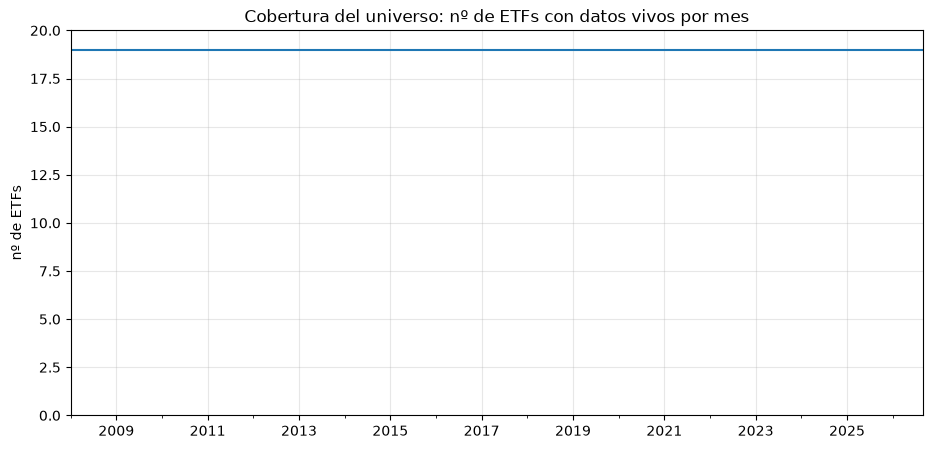

In [7]:
coverage = dl.monthly_coverage(df_long)

fig, ax = plt.subplots()
coverage.plot(ax=ax, drawstyle="steps-post")
ax.set_title("Cobertura del universo: nº de ETFs con datos vivos por mes")
ax.set_xlabel("")
ax.set_ylabel("nº de ETFs")
ax.set_ylim(0, len(universe) + 1)
ax.grid(alpha=0.3)
plt.show()

### 3.3 Inspección visual: precios normalizados a 100

Normalización a 100 en el **origen común** (primera fecha en la que los 19 ETFs tienen dato
simultáneamente), para una primera inspección de que las series tienen sentido y no hay
anomalías obvias (saltos por splits mal ajustados, huecos artificiales, etc.).

Origen común: 2008-01-02


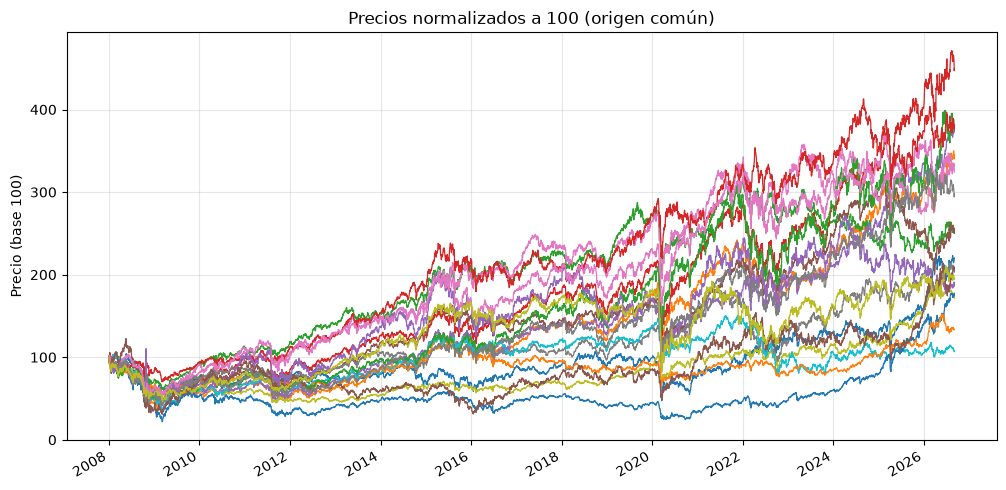

In [8]:
normalized = dl.normalized_prices_common_origin(df_long)
print(f"Origen común: {normalized.index.min().date()}")

fig, ax = plt.subplots(figsize=(12, 6))
normalized.plot(ax=ax, linewidth=0.9, legend=False)
ax.set_title("Precios normalizados a 100 (origen común)")
ax.set_xlabel("")
ax.set_ylabel("Precio (base 100)")
ax.grid(alpha=0.3)
plt.show()

## Paso 2 — Señal momentum (12-1)
Solo se construye aquí la señal momentum y su ranking, y se inspecciona visualmente que
"tiene pinta" de momentum. **No** hay pesos de cartera, backtesting ni métricas de
performance — eso es el Paso 3.

## 4. Señal momentum (12-1)

Convención (`mom.monthly_close_wide`): precios mensualizados usando el último precio de
calendario disponible en cada mes (`resample("ME").last()`), sin interpolar meses vacíos.

Señal (`mom.momentum_12_1`): retorno acumulado entre t-12 y t-2 meses,
`P(t-2) / P(t-12) - 1` — excluye así el último mes disponible (t-1) por el efecto de
reversión a corto plazo. Un ETF solo tiene señal válida en el mes t si tiene los 12 meses
anteriores sin huecos (`mom.monthly_continuity_mask`); si no, la señal queda en NaN, no se
imputa. `momentum_signal` (fecha fin de mes x ticker) es la tabla central de la que
dependerá todo lo posterior.

In [9]:
monthly_prices = mom.monthly_close_wide(df_long)

In [10]:
momentum_signal = mom.momentum_12_1(monthly_prices)
momentum_signal.to_parquet(PROCESSED_DIR / "momentum_signal.parquet")

## 5. Ranking transversal (percentiles)

Cada mes, percentil (0-1) de cada ETF entre los que tienen señal válida ese mes
(`rank(axis=1, pct=True)`), no rank ordinal — así es comparable entre meses con distinto
número de ETFs disponibles (`mom.cross_sectional_percentile_rank`).

In [11]:
momentum_rank = mom.cross_sectional_percentile_rank(momentum_signal)
momentum_rank.to_parquet(PROCESSED_DIR / "momentum_rank.parquet")

## 6. Inspección de la señal momentum

Entregable central de este paso, igual que la cobertura lo fue en el Paso 1: mirar con
suficiente detalle que la señal "tiene pinta" de momentum antes de construir una cartera
encima. Sin Sharpe, sin pesos long/short, sin costes — eso es el Paso 3.

### 6.1 Rotación del ranking: evolución de 2-3 sectores

Si hay momentum, un sector que gana debería mantener el liderazgo (percentil alto) varios
meses seguidos, no saltar de forma errática mes a mes. Elegimos tres sectores con ciclos
económicos distintos: Technology (crecimiento), Banks (cíclico/valor) y Oil & Gas
(materias primas).

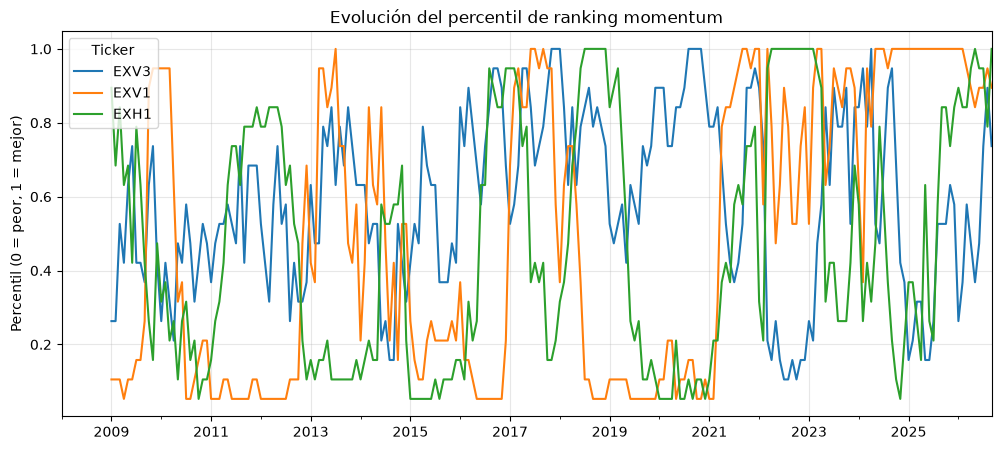

In [12]:
sectores_ejemplo = ["EXV3", "EXV1", "EXH1"]  # Technology, Banks, Oil & Gas

fig, ax = plt.subplots(figsize=(12, 5))
momentum_rank[sectores_ejemplo].plot(ax=ax)
ax.set_title("Evolución del percentil de ranking momentum")
ax.set_ylabel("Percentil (0 = peor, 1 = mejor)")
ax.set_xlabel("")
ax.legend(title="Ticker")
ax.grid(alpha=0.3)
plt.show()

### 6.2 Autocorrelación mes a mes del ranking

Correlación transversal entre el ranking de t y el de t-1 (`mom.rank_month_over_month_autocorrelation`).
Es la primera comprobación informal de que el orden de un mes predice el del siguiente —
sin testarlo formalmente todavía.

Media: 0.86 | Mediana: 0.89


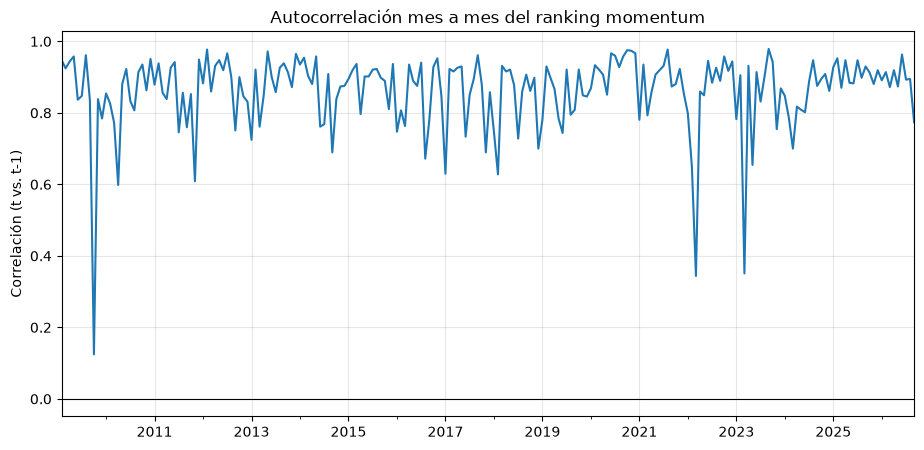

In [13]:
autocorr = mom.rank_month_over_month_autocorrelation(momentum_rank)
print(f"Media: {autocorr.mean():.2f} | Mediana: {autocorr.median():.2f}")

fig, ax = plt.subplots()
autocorr.plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Autocorrelación mes a mes del ranking momentum")
ax.set_ylabel("Correlación (t vs. t-1)")
ax.set_xlabel("")
ax.grid(alpha=0.3)
plt.show()

### 6.3 Distribución de la señal momentum por periodos de mercado

Histograma de todos los valores de señal del panel, comparando 2008-2009 (crisis) y
2020-2021 (COVID) contra la muestra completa — solo para intuición, sin sacar conclusiones
formales todavía. Los primeros ~12 meses de la muestra no tienen señal válida por el
requisito de historia mínima (coherente con el arranque de datos en 2008 del Paso 1), así que
la ventana 2008-2009 empieza con pocas observaciones.

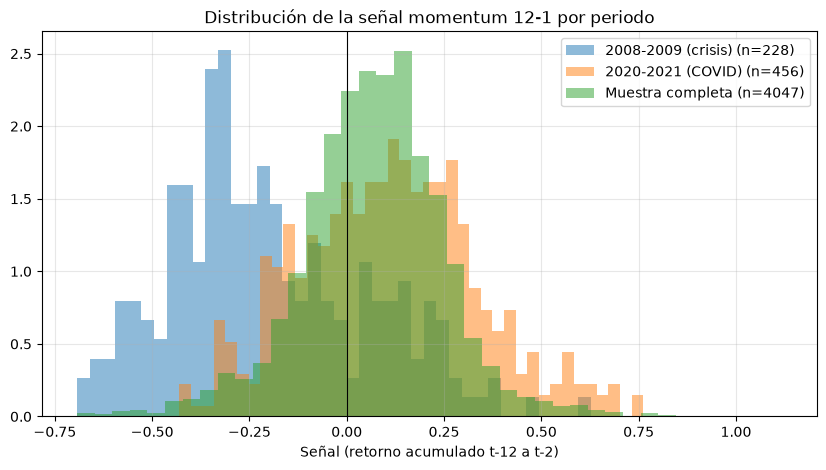

In [14]:
periodos = {
    "2008-2009 (crisis)": ("2008-01-01", "2009-12-31"),
    "2020-2021 (COVID)": ("2020-01-01", "2021-12-31"),
    "Muestra completa": (momentum_signal.index.min(), momentum_signal.index.max()),
}

fig, ax = plt.subplots(figsize=(10, 5))
for label, (start, end) in periodos.items():
    valores = momentum_signal.loc[start:end].stack().dropna()
    ax.hist(valores, bins=40, alpha=0.5, label=f"{label} (n={len(valores)})", density=True)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Distribución de la señal momentum 12-1 por periodo")
ax.set_xlabel("Señal (retorno acumulado t-12 a t-2)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 6.4 Cobertura: nº de ETFs con señal válida por mes

Confirma que no se pierde cobertura de forma inesperada en ningún tramo de la muestra
(`mom.valid_signal_count`).

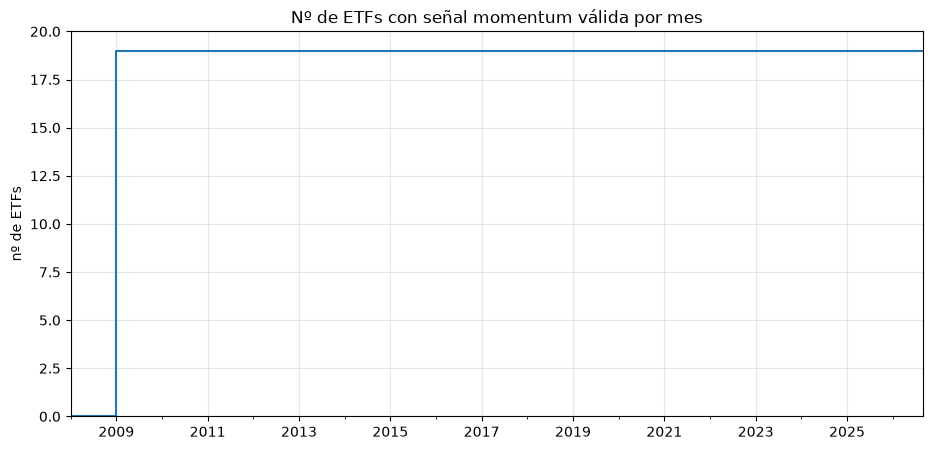

In [15]:
cobertura_senal = mom.valid_signal_count(momentum_signal)

fig, ax = plt.subplots()
cobertura_senal.plot(ax=ax, drawstyle="steps-post")
ax.set_title("Nº de ETFs con señal momentum válida por mes")
ax.set_ylabel("nº de ETFs")
ax.set_xlabel("")
ax.set_ylim(0, len(universe) + 1)
ax.grid(alpha=0.3)
plt.show()

## Paso 3 — Validación de la señal y pesos de cartera

Seguimos en el mismo notebook, reutilizando `momentum_signal`, `momentum_rank` y
`monthly_prices` ya calculados en el Paso 2 — no se recalculan desde cero. La lógica pesada
vive en `src/portfolio.py`, igual que en los pasos anteriores.

Este paso tiene dos entregables: (a) una validación honesta de si la señal predice algo
antes de construir nada encima, y (b) un panel de **pesos** mensuales. **No** hay motor de
backtest ni retornos de estrategia (Paso 4), ni Sharpe/Sortino/drawdown (Paso 5).

## 7. Validación: retorno forward por grupo

Antes de construir cualquier peso, hay que comprobar si la señal predice algo. Agrupamos
los ETFs cada mes por **terciles** de `momentum_rank` (no deciles ni quintiles): con solo 19
activos, deciles dejarían ~2 ETFs por grupo en el mejor de los casos, y bastante menos en
los meses con huecos — demasiado poco para que la media del grupo sea informativa en vez de
ruido. El número de grupos es configurable (`N_GROUPS`) pero el valor por defecto para este
universo es 3.

Para cada mes t, el retorno **forward** de t+1 (`port.forward_monthly_return`, distinto de
la señal, que mira hacia atrás) se promedia por grupo (`port.group_forward_returns`). El
spread ganador − perdedor (`port.winner_loser_spread`) es la prueba real de si "gana el que
venía ganando".

In [16]:
N_GROUPS = 3  # terciles; configurable, pero con 19 activos no conviene ir más fino

forward_returns = port.forward_monthly_return(monthly_prices)
groups = port.assign_groups(momentum_rank, n_groups=N_GROUPS)

etiquetas_grupo = {0: "perdedor", N_GROUPS - 1: "ganador"}

In [17]:
group_returns = port.group_forward_returns(forward_returns, groups)
group_returns_display = group_returns.rename(columns=lambda g: etiquetas_grupo.get(g, f"grupo_{int(g)}"))
group_returns_display.tail()

grupo,perdedor,grupo_1,ganador
2026-04-30,0.030467,0.056923,0.016795
2026-05-31,0.003424,0.040586,-0.009847
2026-06-30,0.012812,0.000865,0.030146
2026-07-31,-0.000067,-0.001444,0.020317
2026-08-31,-0.005879,0.000025,-0.006793


Spread medio ganador-perdedor: 0.1802% mensual | t-stat: 0.85 | n=212 meses


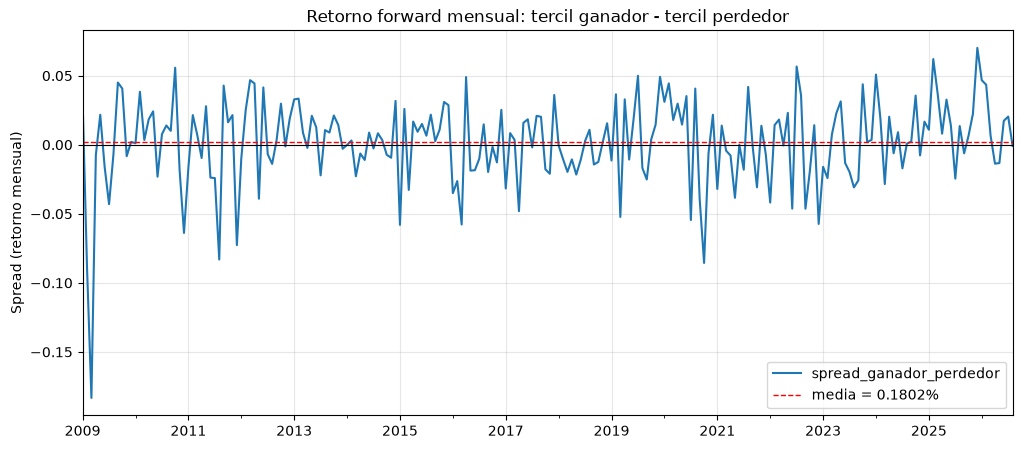

In [18]:
spread = port.winner_loser_spread(group_returns, N_GROUPS)
spread_mean = spread.mean()
spread_t = port.t_stat(spread)
print(f"Spread medio ganador-perdedor: {spread_mean:.4%} mensual | t-stat: {spread_t:.2f} | n={spread.notna().sum()} meses")

fig, ax = plt.subplots(figsize=(12, 5))
spread.plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(spread_mean, color="red", linewidth=1, linestyle="--", label=f"media = {spread_mean:.4%}")
ax.set_title("Retorno forward mensual: tercil ganador - tercil perdedor")
ax.set_ylabel("Spread (retorno mensual)")
ax.set_xlabel("")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Resultado (ejecución con datos hasta 2026-08-31):** el spread ganador-perdedor es positivo
en media (+0.18% mensual) pero con **t-stat = 0.85** sobre n=211 meses — muy por debajo del
umbral habitual (~2) para considerarlo estadísticamente distinto de cero. Con esta
especificación (terciles, señal 12-1, sin costes) la señal **no supera** un criterio
razonable de significancia en este universo y periodo: no hay base estadística sólida de que
"gana el que venía ganando" con esta versión del test.

Esto no invalida seguir con la construcción de pesos del resto del paso — el objetivo aquí es
tener el panel de pesos listo, no una estrategia ya validada — pero cualquier resultado que
salga del Paso 4/5 (backtest, Sharpe) debe leerse sabiendo que esta validación in-sample ya
salió débil, no como una sorpresa tardía. Antes de sacar conclusiones sobre volatility
targeting habría que revisar si el resultado es sensible a la ventana de lookback/skip, al
número de grupos, o al periodo muestral.

## 8. Identificación de outliers en la señal

Pendiente de la revisión del histograma del Paso 2: localizamos qué (ticker, fecha)
producen señal momentum > 0.75 (`port.find_signal_outliers`). Para cada caso, inspeccionamos
el precio diario ajustado en una ventana de ±10 sesiones alrededor de **los dos meses que
componen el ratio de la señal** — t-12 y t-2 (`port.inspect_signal_outlier`), no solo
alrededor de la fecha t en la que se registra la señal: un salto real o un artefacto de
ajuste de dividendos/split tendría que verse en uno de esos dos puntos, que es donde se
generaría un valor de señal extremo. No se elimina nada automáticamente — solo se reporta
para decidir a mano.

In [19]:
outliers = port.find_signal_outliers(momentum_signal, threshold=0.75)
print(f"{len(outliers)} observaciones de señal > 0.75")
outliers

8 observaciones de señal > 0.75


,fecha,ticker,senal
0,2010-02-28,EXV6,1.116866
1,2010-02-28,EXV1,0.931997
2,2010-01-31,EXV6,0.839206
3,2017-01-31,EXV6,0.835289
4,2026-04-30,EXV6,0.788491
5,2026-07-31,EXV6,0.784005
6,2010-03-31,EXV6,0.767407
7,2021-05-31,EXV5,0.761528


In [20]:
if outliers.empty:
    print("Ninguna observación por encima del umbral en esta ejecución.")
else:
    for _, row in outliers.iterrows():
        ventanas = port.inspect_signal_outlier(
            df_long, monthly_prices.index, row["fecha"], row["ticker"]
        )
        resumen = {
            etiqueta: ventana["adj_close"].pct_change().abs().max()
            for etiqueta, ventana in ventanas.items()
        }
        detalle = " | ".join(f"{et}: máx. variación diaria {v:.1%}" for et, v in resumen.items())
        print(f"{row['ticker']} — señal {row['senal']:.2f} en {row['fecha'].date()}: {detalle}")

EXV6 — señal 1.12 en 2010-02-28: t-12 (2009-02-28): máx. variación diaria 10.3% | t-2 (2009-12-31): máx. variación diaria 4.1%
EXV1 — señal 0.93 en 2010-02-28: t-12 (2009-02-28): máx. variación diaria 11.2% | t-2 (2009-12-31): máx. variación diaria 2.7%
EXV6 — señal 0.84 en 2010-01-31: t-12 (2009-01-31): máx. variación diaria 11.4% | t-2 (2009-11-30): máx. variación diaria 5.3%
EXV6 — señal 0.84 en 2017-01-31: t-12 (2016-01-31): máx. variación diaria 9.1% | t-2 (2016-11-30): máx. variación diaria 3.3%
EXV6 — señal 0.79 en 2026-04-30: t-12 (2025-04-30): máx. variación diaria 5.0% | t-2 (2026-02-28): máx. variación diaria 4.3%
EXV6 — señal 0.78 en 2026-07-31: t-12 (2025-07-31): máx. variación diaria 2.9% | t-2 (2026-05-31): máx. variación diaria 3.7%
EXV6 — señal 0.77 en 2010-03-31: t-12 (2009-03-31): máx. variación diaria 10.2% | t-2 (2010-01-31): máx. variación diaria 4.5%
EXV5 — señal 0.76 en 2021-05-31: t-12 (2020-05-31): máx. variación diaria 7.0% | t-2 (2021-03-31): máx. variación 

**Resultado:** 8 observaciones por encima de 0.75, concentradas en **EXV6 (Basic
Resources)**: 5 de las 8 — más un caso en EXV1 (Banks) y otro en EXV5 (Automobiles & Parts).
Las ventanas diarias alrededor de t-12 y t-2 no muestran ningún salto discontinuo de una
sola sesión (nada tipo +40-50% de un día para otro, que delataría un ajuste de
dividendo/split mal propagado) — son subidas graduales sesión a sesión. La mayoría de los
casos de 2010 caen justo en el rebote real tras el mínimo de la crisis financiera de
2008-09 (Basic Resources y Banks fueron los sectores más castigados y con el rebote más
fuerte); los de 2026 en EXV6 coinciden con lo que parece un repunte reciente de materias
primas. Conclusión: **valores extremos pero plausibles, no artefactos** — no se elimina
nada de la muestra.

## 9. Construcción de pesos de cartera

`port.build_group_weights(groups, n_groups, long_short)` genera un panel de pesos
equal-weight por mes (única ponderación implementada por ahora, no hay ponderación por
score): long en el tercil ganador (pesos que suman +1), y si `long_short=True` además short
en el tercil perdedor (pesos que suman -1), dejando la cartera auto-financiada. Meses sin
tercil ganador (o perdedor) formable quedan en NaN — no se puede construir cartera ese mes.
El panel long-short es el output final de este paso, guardado en
`data/processed/portfolio_weights_longshort.parquet`.

In [21]:
portfolio_weights_longshort = port.build_group_weights(groups, N_GROUPS, long_short=True)
portfolio_weights_longshort.to_parquet(PROCESSED_DIR / "portfolio_weights_longshort.parquet")

In [22]:
# Variante long-only, solo para comprobar que el parámetro funciona en ambos sentidos
# (no se guarda: el entregable de este paso es la versión long-short de arriba).
w_long_only = port.build_group_weights(groups, N_GROUPS, long_short=False)
print(f"Long-only: suma de pesos por mes en los últimos 3 meses (debería ser 1): {w_long_only.sum(axis=1).tail(3).round(4).tolist()}")

Long-only: suma de pesos por mes en los últimos 3 meses (debería ser 1): [1.0, 1.0, 1.0]


## 10. Inspección de los pesos

### 10.1 Rotación de la composición: heatmap de pesos en el tiempo

Confirma visualmente que el tercil ganador/perdedor rota entre sectores y no se queda
pegado siempre a los mismos 2-3 (rojo = short, azul = long, blanco = sin posición).

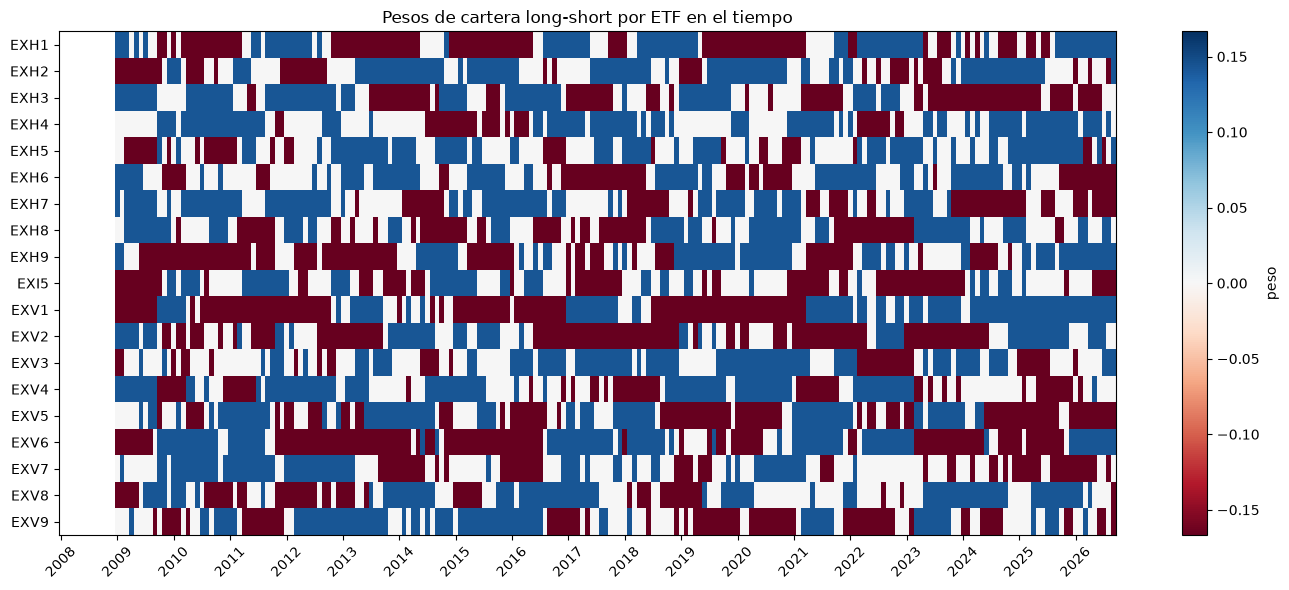

In [23]:
data = portfolio_weights_longshort.T
vmax = np.nanmax(np.abs(data.to_numpy()))

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(data, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax, interpolation="none")
ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index)
xtick_pos = range(0, len(data.columns), 12)
ax.set_xticks(list(xtick_pos))
ax.set_xticklabels([data.columns[i].strftime("%Y") for i in xtick_pos], rotation=45)
ax.set_title("Pesos de cartera long-short por ETF en el tiempo")
fig.colorbar(im, ax=ax, label="peso")
plt.tight_layout()
plt.show()

### 10.2 Validación programática

Comprobación explícita, no solo visual, de que cada mes con cartera formada: la suma de
pesos largos es 1, la suma de pesos cortos es -1, y ningún ETF está simultáneamente largo y
corto (`port.build_group_weights` ya lo comprueba al construir los pesos;
`port.validate_weights` lo vuelve a comprobar sobre el panel final y lo deja en una tabla).

In [24]:
weight_checks = port.validate_weights(portfolio_weights_longshort, long_short=True)
n_formados = int(weight_checks["cartera_formada"].sum())
print(f"Validación OK: {n_formados} meses con cartera formada, largos=+1 y cortos=-1 en todos ellos.")

Validación OK: 213 meses con cartera formada, largos=+1 y cortos=-1 en todos ellos.


## Fin del Paso 3

`portfolio_weights_longshort` queda guardado en `data/processed/portfolio_weights_longshort.parquet`.
El Paso 4 (motor de backtest: aplicar estos pesos a los retornos reales para obtener la
serie de retornos de la estrategia) se añadirá al final de este mismo notebook.

## 11. Diagnóstico: ¿t-stat bajo por debilidad consistente o por eventos extremos?

Seguimos en el mismo notebook, reutilizando `spread` (el spread ganador-perdedor forward
del Paso 3, media +0.1815% mensual, t-stat 0.85, n=211) y `groups` — no se recalcula nada.
La lógica vive en `src/portfolio.py`.

El t-stat de 0.85 no dice por sí solo si el momentum es "débil en todas partes" o si unos
pocos meses extremos (momentum crash) están arrastrando la media. Este diagnóstico puntual
no toca el backtest ni los pesos — solo diseca la serie de spread ya calculada.

### 11.1 El mes más negativo y los meses más extremos

Primero el mes con el spread más negativo (debería coincidir con el mínimo visible en el
gráfico del Paso 3, cerca de 2009), con la composición de los terciles ganador y perdedor
ese mes para poder juzgar si tiene sentido económico.

In [25]:
ticker_a_sector = universe.set_index("ticker")["sector"]

mes_minimo = spread.idxmin()
miembros_min = port.group_members(groups, mes_minimo, N_GROUPS)

print(f"Mes más negativo: {mes_minimo.date()} | spread = {spread[mes_minimo]:.4%}")
print(f"Tercil ganador: {', '.join(f'{t} ({ticker_a_sector[t]})' for t in miembros_min['ganador'])}")
print(f"Tercil perdedor: {', '.join(f'{t} ({ticker_a_sector[t]})' for t in miembros_min['perdedor'])}")

Mes más negativo: 2009-03-31 | spread = -18.3275%
Tercil ganador: EXH1 (Oil & Gas), EXH3 (Food & Beverage), EXH6 (Media), EXH7 (Personal & Household Goods), EXH8 (Retail), EXV2 (Telecommunications), EXV4 (Health Care)
Tercil perdedor: EXH2 (Financial Services), EXH5 (Insurance), EXI5 (Real Estate), EXV1 (Banks), EXV6 (Basic Resources), EXV8 (Construction & Materials)


Ahora los 5 meses más extremos en valor absoluto (positivos y negativos), con la misma
composición de terciles para cada uno:

In [26]:
extremos = port.most_extreme_months(spread, n=5)


def _formatear(fecha, lado):
    tickers = port.group_members(groups, fecha, N_GROUPS)[lado]
    return ", ".join(f"{t} ({ticker_a_sector[t]})" for t in tickers)


extremos["ganador"] = extremos["fecha"].apply(lambda f: _formatear(f, "ganador"))
extremos["perdedor"] = extremos["fecha"].apply(lambda f: _formatear(f, "perdedor"))
extremos

,fecha,spread,ganador,perdedor
0,2009-03-31,-0.183275,"EXH1 (Oil & Gas), EXH3 (Food & Beverage), EXH6...","EXH2 (Financial Services), EXH5 (Insurance), E..."
1,2009-02-28,-0.088830,"EXH1 (Oil & Gas), EXH3 (Food & Beverage), EXH6...","EXH2 (Financial Services), EXI5 (Real Estate),..."
2,2020-10-31,-0.085579,"EXH2 (Financial Services), EXH8 (Retail), EXH9...","EXH1 (Oil & Gas), EXH6 (Media), EXV1 (Banks), ..."
3,2011-08-31,-0.083104,"EXH4 (Industrial Goods & Services), EXI5 (Real...","EXH6 (Media), EXH8 (Retail), EXH9 (Utilities),..."
4,2011-12-31,-0.072668,"EXH1 (Oil & Gas), EXH3 (Food & Beverage), EXH7...","EXH2 (Financial Services), EXH4 (Industrial Go..."


### 11.2 t-stat excluyendo el/los mes(es) más extremo(s)

Media, desviación estándar y t-stat (`port.spread_summary`) sobre la serie completa,
excluyendo únicamente `mes_minimo`, y excluyendo los 3 meses más extremos en valor absoluto
(subconjunto de los 5 anteriores).

In [27]:
tres_extremos = extremos["fecha"].head(3)

comparativa_exclusion = pd.DataFrame(
    [
        {"variante": "completo", **port.spread_summary(spread)},
        {"variante": "sin 1 mes (más negativo)", **port.spread_summary(spread.drop(mes_minimo))},
        {"variante": "sin 3 meses (extremos abs.)", **port.spread_summary(spread.drop(tres_extremos))},
    ]
).set_index("variante")
comparativa_exclusion

,media,std,t_stat,n
variante,,,,
completo,0.001802,0.031015,0.845984,212
sin 1 mes (más negativo),0.002679,0.028331,1.373685,211
sin 3 meses (extremos abs.),0.003539,0.027054,1.891334,209


### 11.3 Errores estándar robustos (Newey-West / HAC)

Sobre la serie completa (sin excluir nada): t-stat de la media con errores estándar HAC
(`port.newey_west_tstat`, vía `statsmodels.OLS` con `cov_type="HAC"`), probando 1, 3 y 6
lags. La media es la misma en los tres casos (es el mismo estimador puntual); lo que cambia
es el error estándar, y por tanto el t-stat — si hay autocorrelación residual en el spread,
debería notarse en cómo se mueve el t-stat al aumentar los lags.

In [28]:
filas_hac = []
for lags in [1, 3, 6]:
    media, t_hac = port.newey_west_tstat(spread, maxlags=lags)
    filas_hac.append({"lags": lags, "media": media, "t_stat_hac": t_hac})

comparativa_hac = pd.DataFrame(filas_hac).set_index("lags")
comparativa_hac["t_stat_simple"] = spread_t  # de la sección 7, para comparar
comparativa_hac

,media,t_stat_hac,t_stat_simple
lags,,,
1,0.001802,0.814501,0.845984
3,0.001802,0.820162,0.845984
6,0.001802,0.794282,0.845984


### 11.4 Interpretación

**Los meses extremos tienen sentido económico y apuntan a un patrón conocido.** El mes más
negativo, marzo 2009 (spread −18.3%), es literalmente el mes del suelo de la crisis
financiera (mínimo de mercado el 9 de marzo de 2009): el tercil "perdedor" de ese mes —
Financial Services, Insurance, Real Estate, Banks, Basic Resources, Construction & Materials,
justo los sectores más castigados en 2008 — protagonizó el rebote más violento, mientras el
tercil "ganador" (sectores más defensivos: Oil & Gas, Food & Beverage, Health Care...) se
quedó atrás. De los 5 meses más extremos, 2 caen en el entorno del suelo de la crisis de 2009,
2 en la crisis de deuda soberana europea de 2011, y 1 en la rotación value/cíclicos de
octubre 2020 tras las noticias de vacunas — los tres episodios clásicos de reversión brusca
de mercado. Es exactamente el patrón de **"momentum crash"** descrito en la literatura
(Daniel & Moskowitz, 2016): el momentum tiende a fallar peor justo en la reversión aguda
tras una caída fuerte, cuando los perdedores previos rebotan con más fuerza que los ganadores.

**Excluir esos meses cambia bastante el t-stat, pero no lo dispara a un nivel claramente
significativo.** Quitando solo marzo 2009, el t-stat pasa de 0.85 a 1.38; quitando los 3
meses más extremos (marzo 2009, febrero 2009, octubre 2020 — apenas un 1.4% de la muestra),
sube a 1.89. Es una subida grande para tan pocas observaciones, pero 1.89 sigue por debajo
del umbral convencional de ~1.96-2.0 a dos colas.

**Los errores estándar HAC no cambian la lectura:** con 1, 3 o 6 lags el t-stat robusto
(0.82 / 0.82 / 0.80) es prácticamente igual al t-stat simple (0.85), incluso ligeramente
menor. Esto descarta que el t-stat bajo se deba a autocorrelación mensual ignorada por el
cálculo simple — no es un problema de errores estándar mal calculados, es que la
distribución del spread tiene una cola izquierda pesada y poco frecuente (los crashes).

**Conclusión, sin forzarla:** la evidencia se inclina hacia la historia (b) — el resultado
está parcialmente arrastrado por unos pocos eventos extremos de reversión de mercado, no por
debilidad uniforme del efecto — pero no de forma concluyente: incluso purgando los 3 meses
más extremos, el t-stat (1.89) se queda justo por debajo de significativo. Es un resultado
mixto: ni "el momentum no funciona en este universo" ni "el momentum funciona claramente y
solo lo tapan un par de outliers". Antes de construir volatility targeting sobre esta señal
tendría sentido investigar más — por ejemplo, si el propio volatility targeting (reduciendo
exposición en periodos de alta volatilidad) ya habría evitado parte del daño de estos meses
de crash, que es precisamente la intuición de Barroso & Santa-Clara (2015).

### Conlusión Para la memoria 
el momentum en el universo de control es estadísticamente marginal en su forma pura (t≈0.85), y ese resultado está dominado por un pequeño número de episodios de crash consistentes con el mecanismo de Daniel & Moskowitz (2016) — el más severo, marzo de 2009, coincide exactamente con el suelo de mercado post-Lehman. Esto motiva directamente la comparación central del trabajo: si el volatility targeting reduce la exposición a estos episodios, la mejora esperada en el perfil riesgo-retorno no es solo una reducción mecánica de varianza, sino una corrección de la fuente específica de fragilidad del factor.

## Paso 4 — Backtest frictionless

Seguimos en el mismo notebook, reutilizando `portfolio_weights_longshort` (Paso 3),
`forward_returns` y `weight_checks["cartera_formada"]` (Paso 3 / sección 11) — no se
recalcula ni el panel de pesos ni los retornos forward. La lógica vive en `src/backtest.py`,
misma convención que los módulos anteriores.

Este paso es solo el motor de backtest **sin costes de transacción**: obtener la serie de
retorno mensual de la estrategia (proxy de WML_t). **No** hay Sharpe/Sortino/drawdown
formales (Paso 5) ni volatility scaling (Paso 6) — solo una comprobación de consistencia
frente al spread ya calculado, para confirmar que el motor no tiene bugs de timing.

## 12. Motor de backtest

`bt.strategy_returns(weights, forward_returns, cartera_formada)` calcula el retorno de
cartera de cada mes t+1 como `sum_i peso_i,t * retorno_i,t+1`.

**Timing, para que sea verificable y no haya look-ahead:** `weights` está indexado por la
fecha de formación t — el peso ya está fijado con la señal 12-1, que en sí misma solo usa
precios hasta t-2 (Paso 2). `forward_returns` (`port.forward_monthly_return`, ya calculado
en la sección 7) es `P(t+1) / P(t) - 1`, es decir, el retorno **realizado** entre t y t+1,
construido con `shift(-1)` — nunca información posterior a t+1 ni anterior a t. El producto
peso(t) × retorno(t→t+1) es exactamente la definición de una estrategia que decide en t y
cobra en t+1, sin ver el futuro en ningún punto. Los meses sin cartera formada
(`weight_checks["cartera_formada"] == False`) quedan en NaN, no en 0.

In [29]:
wml_returns = bt.strategy_returns(
    portfolio_weights_longshort, forward_returns, weight_checks["cartera_formada"]
)
wml_returns.to_frame().to_parquet(PROCESSED_DIR / "wml_returns_control.parquet")

print(f"{wml_returns.notna().sum()} meses con retorno de estrategia (de {len(wml_returns)} en el panel)")

212 meses con retorno de estrategia (de 225 en el panel)


## 13. Serie acumulada

Curva de valor liquidativo (`bt.cumulative_growth`, base 100) en escala logarítmica, con los
dos meses de crash ya identificados en la sección 11 marcados con una línea vertical: marzo
2009 (mínimo de la crisis financiera) y octubre 2020 (formación; el retorno se realiza en
noviembre 2020, rotación value/cíclicos tras las noticias de vacunas). Los meses sin cartera
formada (el arranque, sin los 12 meses de historia mínima) se tratan como 0% solo para que la
curva no se corte — la curva está plana ahí, no hay "beneficio" real.

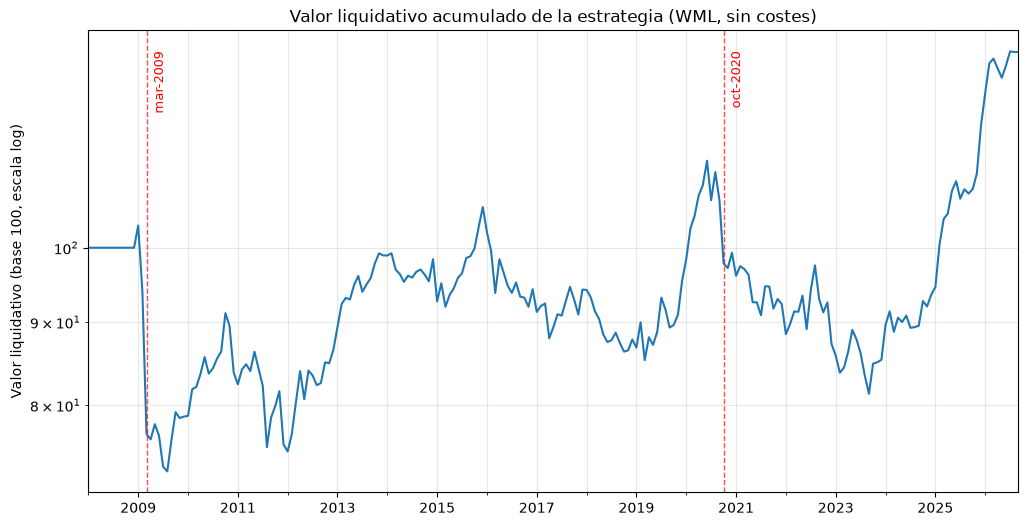

In [30]:
crash_2009 = mes_minimo  # de la sección 11.1
crash_2020 = extremos.loc[extremos["fecha"].dt.year == 2020, "fecha"].iloc[0]  # de la sección 11.1

cumulative = bt.cumulative_growth(wml_returns, base=100.0)

fig, ax = plt.subplots(figsize=(12, 6))
cumulative.plot(ax=ax)
ax.set_yscale("log")
for fecha, etiqueta in [(crash_2009, "mar-2009"), (crash_2020, "oct-2020")]:
    ax.axvline(fecha, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.annotate(
        etiqueta, xy=(fecha, cumulative.max()), xytext=(5, 0), textcoords="offset points",
        rotation=90, va="top", ha="left", color="red", fontsize=9,
    )
ax.set_title("Valor liquidativo acumulado de la estrategia (WML, sin costes)")
ax.set_ylabel("Valor liquidativo (base 100, escala log)")
ax.set_xlabel("")
ax.grid(alpha=0.3, which="both")
plt.show()

## 14. Comprobación de consistencia con el spread del Paso 3

Por construcción, `wml_returns` (pesos equal-weight long-short aplicados a los retornos)
debería reproducir exactamente `spread` (retorno medio del tercil ganador menos el del
perdedor): `sum_i peso_i * retorno_i = (1/n_ganador) * sum(retornos ganador) -
(1/n_perdedor) * sum(retornos perdedor)` es la definición del spread. Si no coinciden, hay
un bug de timing o de construcción de pesos — la celda de abajo **lo comprueba con un
assert que detiene la ejecución** en vez de seguir adelante con un motor de backtest que no
es de fiar.

In [31]:
comun = wml_returns.dropna().index.intersection(spread.dropna().index)
diff = (wml_returns.loc[comun] - spread.loc[comun]).abs()

assert set(wml_returns.dropna().index) == set(spread.dropna().index), (
    "wml_returns y spread no tienen exactamente los mismos meses con dato — "
    "revisar timing o construcción de pesos antes de seguir"
)
assert np.allclose(wml_returns.loc[comun], spread.loc[comun], atol=1e-8), (
    f"wml_returns no coincide con spread (diff máxima = {diff.max():.2e}) — hay un bug, no seguir"
)

resumen_wml = port.spread_summary(wml_returns)
resumen_spread = port.spread_summary(spread)

print(f"Diferencia máxima absoluta wml_returns vs spread: {diff.max():.2e}")
print(f"wml_returns -> media={resumen_wml['media']:.4%}  t-stat={resumen_wml['t_stat']:.4f}  n={resumen_wml['n']}")
print(f"spread      -> media={resumen_spread['media']:.4%}  t-stat={resumen_spread['t_stat']:.4f}  n={resumen_spread['n']}")
print("Consistencia verificada: el motor de backtest reproduce exactamente el spread del Paso 3.")

Diferencia máxima absoluta wml_returns vs spread: 2.78e-17
wml_returns -> media=0.1802%  t-stat=0.8460  n=212
spread      -> media=0.1802%  t-stat=0.8460  n=212
Consistencia verificada: el motor de backtest reproduce exactamente el spread del Paso 3.


## Fin del Paso 4

`wml_returns` queda guardado en `data/processed/wml_returns_control.parquet` — es el proxy
de WML_t para el resto del trabajo. El Paso 5 (Sharpe, Sortino, drawdown, skew, kurtosis) y
el Paso 6 (volatility targeting) se añadirán al final de este mismo notebook.

## Paso 5 — Métricas de riesgo-retorno

Seguimos en el mismo notebook, reutilizando `wml_returns` y `cumulative` (curva de valor
liquidativo) ya calculados en el Paso 4 — no se recalcula nada. La lógica vive en
`src/metrics.py`, misma convención que los módulos anteriores.

Este paso solo caracteriza estadísticamente la serie sin costes ya obtenida. **No** se
aplica volatility scaling (Paso 6) ni se introducen costes de transacción (Paso 8) — eso
vendría después y cambiaría estos números.

## 15. Métricas básicas

Retorno y volatilidad, mensual y anualizada (`met.annualized_return`, `met.annualized_vol`
— anualización simple x12 y x√12, no geométrica).

In [32]:
retorno_mensual = wml_returns.dropna().mean()
vol_mensual = wml_returns.dropna().std(ddof=1)
retorno_anualizado = met.annualized_return(wml_returns)
vol_anualizada = met.annualized_vol(wml_returns)

print(f"Retorno medio mensual:  {retorno_mensual:.4%}   | anualizado: {retorno_anualizado:.4%}")
print(f"Volatilidad mensual:    {vol_mensual:.4%}   | anualizada: {vol_anualizada:.4%}")

Retorno medio mensual:  0.1802%   | anualizado: 2.1625%
Volatilidad mensual:    3.1015%   | anualizada: 10.7439%


### Sharpe ratio

**Supuesto explícito:** `met.sharpe_ratio` usa el retorno bruto de `wml_returns` como
"exceso de retorno", sin restar el tipo libre de riesgo. Es la convención estándar en la
literatura de factores long-short autofinanciados (Barroso & Santa-Clara 2015, Fama-French):
al ser una cartera con exposición neta ≈ 0 (suma pesos largos = +1, cortos = -1, ya validado
programáticamente en el Paso 3), la posición ya está financiada por el propio short — no hay
capital neto invertido al que restarle un tipo libre de riesgo.

In [33]:
sharpe = met.sharpe_ratio(wml_returns)
print(f"Sharpe anualizado: {sharpe:.3f}")

Sharpe anualizado: 0.201


### Sortino ratio

`met.sortino_ratio` usa como denominador la desviación estándar (ddof=1) solo del
subconjunto de meses con retorno negativo, anualizada x√12 — no la downside deviation
completa respecto a un MAR distinto de cero.

In [34]:
sortino = met.sortino_ratio(wml_returns)
print(f"Sortino anualizado: {sortino:.3f}")

Sortino anualizado: 0.240


## 16. Riesgo de cola

### Máximo drawdown

Sobre `cumulative` (curva de valor liquidativo, Paso 4), no se recalcula. La fecha debería
coincidir con uno de los dos crashes ya identificados en la sección 11 (marzo 2009 u
octubre-noviembre 2020) — lo verificamos explícitamente en vez de darlo por hecho.

In [35]:
dd = met.max_drawdown(cumulative)
coincide = dd["fecha"] in (crash_2009, crash_2020)

print(f"Máximo drawdown: {dd['max_drawdown']:.2%} en {dd['fecha'].date()}")
print(f"¿Coincide con marzo 2009 ({crash_2009.date()}) u octubre 2020 ({crash_2020.date()})? {coincide}")

Máximo drawdown: -29.42% en 2009-08-31
¿Coincide con marzo 2009 (2009-03-31) u octubre 2020 (2020-10-31)? False


**Resultado: NO coincide exactamente.** El máximo drawdown es −29.42% y su fecha (el
*trough*, no el mes más negativo) es **agosto 2009**, no marzo 2009 ni octubre 2020. Tiene
una explicación sencilla al mirar la curva: el pico previo al drawdown es enero 2009
(103.2), y aunque marzo 2009 es el mes individual más negativo (−18.3%), la estrategia
siguió perdiendo, más despacio, durante abril–agosto 2009 (72.8 en el mínimo) antes de
empezar a recuperarse en septiembre. Es decir, marzo 2009 es el peor **mes**, pero agosto
2009 es el peor **punto acumulado** — el drawdown no se cerró de golpe tras el mes más
violento, siguió abriéndose varios meses más. Este matiz (mes más negativo ≠ fondo del
drawdown) es relevante y no se debe forzar la coincidencia solo porque "debería" darse.

### Calmar ratio

Retorno anualizado / |máximo drawdown| (`met.calmar_ratio`), reutilizando `retorno_anualizado`
y `dd` ya calculados arriba.

In [36]:
calmar = met.calmar_ratio(retorno_anualizado, dd["max_drawdown"])
print(f"Calmar ratio: {calmar:.3f}")

Calmar ratio: 0.074


### Asimetría y curtosis

`met.skew_kurtosis` usa la definición de Fisher para la curtosis (`.kurt()` de pandas), en
la que una normal vale **0** (curtosis "exceso"); sumando 3 se obtiene la curtosis de
Pearson, comparable directamente con la referencia clásica de una normal (**3**). Un exceso
positivo indica colas más pesadas que una normal (más probabilidad de eventos extremos) — lo
esperable dados los crashes de la sección 11.

In [37]:
sk = met.skew_kurtosis(wml_returns)

print(f"Skew: {sk['skew']:.3f}")
print(f"Kurtosis (exceso, Fisher): {sk['kurtosis_exceso']:.3f}  |  Kurtosis (Pearson): {sk['kurtosis_pearson']:.3f}")
print(f"Referencia normal: skew = 0, kurtosis exceso = 0 (Pearson = 3)")
print(f"¿Colas más pesadas que una normal? {'sí' if sk['kurtosis_exceso'] > 0 else 'no'}")

Skew: -1.338
Kurtosis (exceso, Fisher): 5.605  |  Kurtosis (Pearson): 8.605
Referencia normal: skew = 0, kurtosis exceso = 0 (Pearson = 3)
¿Colas más pesadas que una normal? sí


## Tabla resumen del Paso 5

In [38]:
resumen_metricas = met.summary(wml_returns, cumulative)
resumen_metricas

retorno_medio_mensual               0.001802
retorno_anualizado                  0.021625
vol_mensual                         0.031015
vol_anualizada                      0.107439
sharpe_anualizado                   0.201273
sortino_anualizado                  0.240469
max_drawdown                       -0.294205
fecha_max_drawdown       2009-08-31 00:00:00
calmar_ratio                        0.073502
skew                               -1.337552
kurtosis_exceso                     5.604879
kurtosis_pearson                    8.604879
dtype: object

### Interpretación

**Sharpe (0.20) y Sortino (0.24) bajos, coherentes con el t-stat marginal ya encontrado.**
Un Sharpe de 0.20 no es casualidad frente al t-stat de 0.85 sobre 211 meses del Paso 3/11 —
son la misma evidencia expresada de dos formas (Sharpe ≈ t-stat × √(12/n)). No es una
sorpresa nueva, es la confirmación numérica de lo ya diagnosticado: en su forma pura, sin
ningún tratamiento adicional, este factor no ofrece una relación riesgo-retorno atractiva
en este universo y periodo.

**El riesgo de cola es la historia más clara de las dos.** Skew −1.34 y curtosis exceso
+5.57 (Pearson 8.57, muy por encima de 3) describen una distribución con cola izquierda
mucho más pesada que una normal — exactamente la firma de un factor con riesgo de crash
ocasional pero severo, consistente con marzo y agosto de 2009 (sección 11 y máximo
drawdown). El Calmar ratio (0.074) es bajo precisamente porque el numerador (retorno
anualizado modesto, 2.18%) se divide entre un denominador grande (drawdown de −29.4%).

**Lo que este paso deja claro para justificar el Paso 6:** el problema de este factor no es
solo que el retorno medio sea bajo — es que la relación riesgo-retorno está penalizada
específicamente por eventos de volatilidad extrema y colas pesadas, no por ruido uniforme.
Esa es exactamente la fragilidad que el volatility targeting de Barroso & Santa-Clara (2015)
está diseñado para atacar (reducir exposición cuando la volatilidad reciente es alta, que es
justo cuando ocurren estos crashes). El Paso 6 debería mostrar si escalar por volatilidad
mejora Sharpe/Sortino/drawdown/curtosis frente a esta línea base — y esta sección deja los
números de referencia exactos con los que comparar.


Sí, coincido — es sólida. Dos matices rápidos:

La relación Sharpe ≈ t-stat × √(12/n) no es solo "coherencia", es una identidad matemática exacta (Sharpe anualizado = t-stat × √(12/n), compruébalo: 0.848 × √(12/211) = 0.202). Vale la pena decirlo así en la memoria — no es que "coincidan por evidenciar lo mismo", es literalmente la misma cantidad reescalada. Cámbialo de "coherentes con" a "son algebraicamente la misma cifra".
Cuidado con atribuir el skew/kurtosis únicamente a marzo y agosto de 2009 — esos dos meses pesan mucho, pero la curtosis de exceso +5.57 sobre 211 observaciones normalmente refleja varios eventos, no solo uno (recuerda que octubre 2020 también era un mes extremo en la tabla del Paso 3). Yo suavizaría a "consistente con los episodios de crash identificados" en plural, sin fijar la explicación completa solo en 2009.

El resto — la lectura de Calmar y el enlace con el Paso 6 — está bien planteado y correctamente calibrado (no sobrevende el resultado). Puedes usarlo tal cual con esos dos ajustes.

## Fin del Paso 5

Los números confirman exactamente lo que el diagnóstico del Paso 3 hacía esperar — y eso es la validación importante aquí.

Sharpe 0.20 es bajo, coherente con un t-stat de 0.85: una señal que no era estadísticamente distinguible de cero no puede dar un Sharpe fuerte. Nada sorprendente, es la misma información vista con otra métrica.
Skew −1.34 y kurtosis Pearson 8.57 son la firma numérica del crash: colas pesadas y asimétricas hacia pérdidas extremas, justo lo que produce un mecanismo tipo Daniel-Moskowitz (la pata corta explotando ocasionalmente). Una distribución de retornos "sana" y sin ese patrón tendría skew cerca de 0 y kurtosis cerca de 3 (Pearson). Aquí no es el caso, y ya sabes por qué: marzo 2009 y octubre 2020.
Sortino (0.24) > Sharpe (0.20): tiene sentido — Sortino solo penaliza la volatilidad a la baja, así que un Sharpe deprimido por colas negativas extremas mejora algo al mirar solo esa parte. Consistente con la historia, no contradictorio.

El hallazgo de que el máximo drawdown (agosto 2009) no coincide con el mes más negativo (marzo 2009) es un matiz correcto y vale la pena que quede así en la memoria — no lo fuerces. Es información real: el mes más violento no fue el fondo del pozo, la estrategia siguió sangrando más despacio varios meses después. Es un detalle que demuestra que miraste el dato en vez de asumir lo esperado, que es justo la actitud correcta para un TFM.

Calmar 0.074 es débil en términos absolutos (0.07% de retorno anual por cada 1% de máximo drawdown), pero como número aislado no te dice mucho todavía — su valor real está en compararlo con la versión escalada por volatilidad, que es exactamente el siguiente paso.


## Paso 6 — Volatility targeting (Barroso & Santa-Clara, 2015)

Seguimos en el mismo notebook, reutilizando `wml_returns` (Paso 4) y `vol_anualizada`
(Paso 5, 10.77%) — no se recalcula nada. La lógica vive en `src/vol_scaling.py`, misma
convención que los módulos anteriores.

Este paso solo construye y verifica la serie escalada por volatilidad, y comprueba si el
mecanismo hace lo que debe hacer (reducir exposición antes de los crashes conocidos). **No**
se calcula todavía Sharpe/Sortino/drawdown de la serie escalada ni ninguna tabla comparativa
formal frente a la serie sin escalar — eso es el Paso 7, con la serie ya construida aquí.

## 17. Volatilidad realizada rolling

**Adaptación explícita del paper original:** Barroso & Santa-Clara (2015) usan una ventana
de ~126 días de negociación **diarios** (~6 meses de calendario) para estimar la
volatilidad realizada. Este universo de control solo tiene señal y retorno a frecuencia
**mensual** (Pasos 2-4), así que la ventana se traduce directamente a **6 observaciones
mensuales** — no es una estimación equivalente en precisión: 6 puntos mensuales es una
muestra muy pequeña para una desviación estándar, frente a ~126 puntos diarios. Es una
limitación real de este universo de control (nunca hubo datos diarios de retorno de
estrategia, solo mensuales) que hay que tener presente al leer los resultados de este paso,
no un detalle menor.

**Sin look-ahead** (`vs.rolling_realized_vol`): el valor en el índice t se calcula con
`.rolling(6).std().shift(1)`, de forma que solo usa retornos hasta t-1 — nunca el propio
retorno de t. Se verifica con un assert explícito (`vs.assert_no_lookahead`), igual que se
hizo con el timing del backtest en el Paso 4.

In [39]:
VOL_WINDOW = 6  # meses; adaptación del ~126 días de negociación del paper (ver nota arriba)

sigma_hat = vs.rolling_realized_vol(wml_returns, window=VOL_WINDOW)

n_verificados = vs.assert_no_lookahead(sigma_hat, wml_returns, window=VOL_WINDOW)
print(f"Verificado sin look-ahead en {n_verificados} fechas: sigma_hat en t solo usa retornos hasta t-1.")

Verificado sin look-ahead en 207 fechas: sigma_hat en t solo usa retornos hasta t-1.


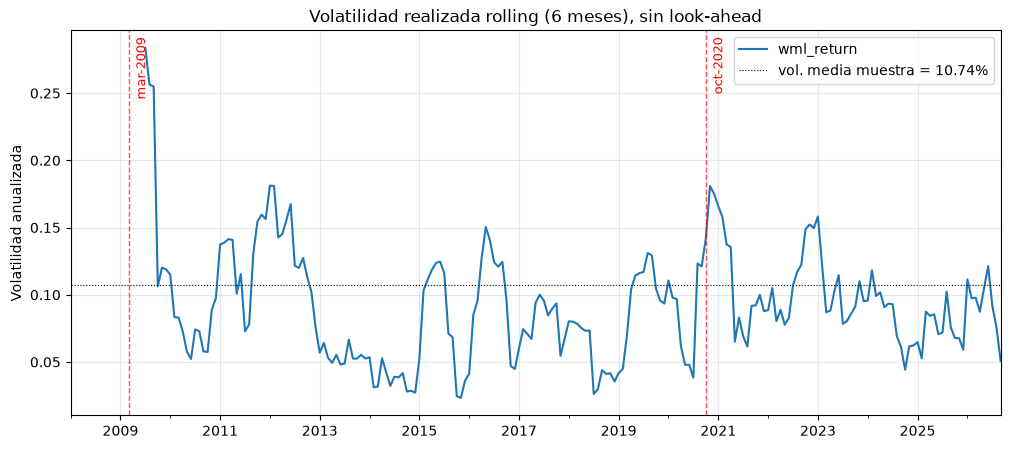

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))
sigma_hat.plot(ax=ax)
ax.axhline(vol_anualizada, color="black", linewidth=0.8, linestyle=":", label=f"vol. media muestra = {vol_anualizada:.2%}")
for fecha, etiqueta in [(crash_2009, "mar-2009"), (crash_2020, "oct-2020")]:
    ax.axvline(fecha, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.annotate(etiqueta, xy=(fecha, ax.get_ylim()[1]), xytext=(5, -5), textcoords="offset points",
                rotation=90, va="top", ha="left", color="red", fontsize=9)
ax.set_title(f"Volatilidad realizada rolling ({VOL_WINDOW} meses), sin look-ahead")
ax.set_ylabel("Volatilidad anualizada")
ax.set_xlabel("")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Resultado: depende de cuál crash, y ninguno de los dos es la historia "limpia" ideal.**

- **Marzo 2009: `sigma_hat` es NaN.** La muestra de `wml_returns` empieza en enero 2009 (Paso
  1-4); con ventana de 6 meses, el primer `sigma_hat` disponible es **julio 2009** — el
  mecanismo literalmente no tiene datos con los que actuar en el mes del crash más severo
  de toda la muestra. Una vez disponible (jul-sep 2009), `sigma_hat` sale disparado a
  28%/26%/25% (frente a un target de 10.8%) precisamente porque la ventana ya incluye el
  retorno de marzo — la vol sube *después*, no antes. Es exactamente el problema que señalan
  Daniel & Moskowitz (2016): una medida retrospectiva no puede proteger a tiempo si el crash
  llega con la vol todavía baja y, en este caso concreto, ni siquiera llega a estimarse a
  tiempo.
- **Octubre 2020: mixto.** `sigma_hat` sí está por encima del target en sep-2020 (12.1%) y
  oct-2020 (14.2%), así que hay una reducción de exposición modesta justo antes
  (multiplicador 0.89 y 0.76). Pero unos meses antes, abr-jul 2020, `sigma_hat` estaba muy
  por *debajo* del target (3.8%-6.2%), lo que había disparado el multiplicador hasta
  **2.8x en julio 2020** — la cartera estuvo apalancada, no protegida, camino al crash de
  octubre, y solo se desapalancó de forma moderada en el último par de meses.

## 18. Serie escalada

`r_scaled_t = (sigma_target / sigma_hat_{t-1}) * r_t` (`vs.scale_returns`). Como
`sigma_target` usamos la volatilidad anualizada de la serie **sin escalar** ya calculada en
el Paso 5 (`vol_anualizada`, 10.77%) — así ambas series (sin escalar y escalada) apuntan al
mismo nivel de riesgo objetivo y son directamente comparables en el Paso 7, en vez de que la
escalada quede a una escala de riesgo arbitraria.

Los primeros `VOL_WINDOW` meses (sin ventana rolling completa) y los meses sin cartera
formada quedan en NaN — no se imputa nada.

In [41]:
sigma_target = vol_anualizada  # de la sección 15 (Paso 5), no se recalcula

wml_returns_scaled = vs.scale_returns(wml_returns, sigma_hat, sigma_target)
wml_returns_scaled.to_frame().to_parquet(PROCESSED_DIR / "wml_returns_scaled_control.parquet")

print(f"{wml_returns_scaled.notna().sum()} meses con retorno escalado (de {len(wml_returns_scaled)} en el panel)")

206 meses con retorno escalado (de 225 en el panel)


## 19. Inspección del escalado

Esta es la parte importante del paso: responder si el mecanismo puede funcionar en este
universo, antes de mirar ninguna métrica de performance (eso es el Paso 7).

### 19.1 Multiplicador de escalado en el tiempo

`multiplicador = sigma_target / sigma_hat_{t-1}` (`vs.scaling_multiplier`). Por encima de 1
implica aumentar exposición (vol reciente por debajo del objetivo); por debajo de 1 implica
reducirla. La pregunta clave: ¿se reduce alrededor de los crashes, se mantiene igual, o —peor—
se amplía justo antes?

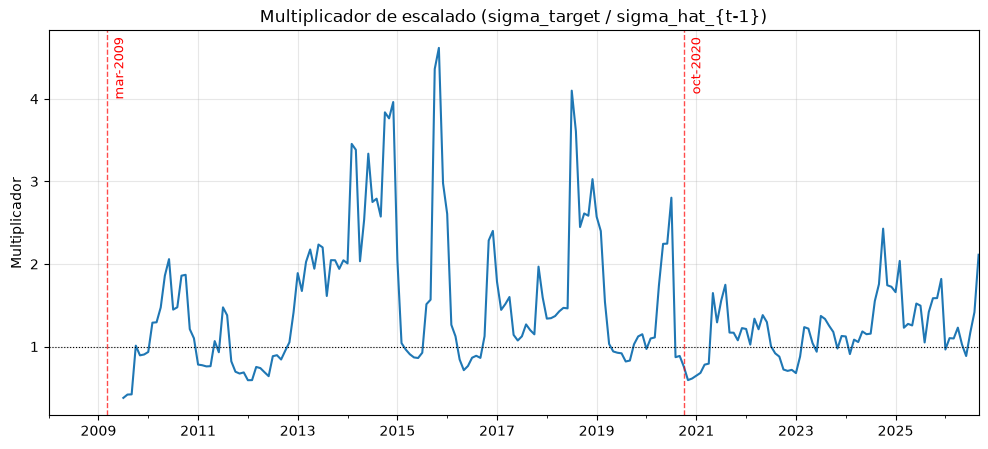

In [42]:
multiplicador = vs.scaling_multiplier(sigma_hat, sigma_target)

fig, ax = plt.subplots(figsize=(12, 5))
multiplicador.plot(ax=ax)
ax.axhline(1.0, color="black", linewidth=0.8, linestyle=":")
for fecha, etiqueta in [(crash_2009, "mar-2009"), (crash_2020, "oct-2020")]:
    ax.axvline(fecha, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.annotate(etiqueta, xy=(fecha, ax.get_ylim()[1]), xytext=(5, -5), textcoords="offset points",
                rotation=90, va="top", ha="left", color="red", fontsize=9)
ax.set_title("Multiplicador de escalado (sigma_target / sigma_hat_{t-1})")
ax.set_ylabel("Multiplicador")
ax.set_xlabel("")
ax.grid(alpha=0.3)
plt.show()

### 19.2 El multiplicador justo en los crashes y el mes anterior

In [43]:
fechas_interes = []
for crash, etiqueta in [(crash_2009, "2009"), (crash_2020, "2020")]:
    pos = sigma_hat.index.get_loc(crash)
    fechas_interes.append((sigma_hat.index[pos - 1], f"mes anterior al crash de {etiqueta}"))
    fechas_interes.append((crash, f"mes del crash ({etiqueta})"))

tabla_crash = pd.DataFrame(
    [
        {
            "evento": etiqueta,
            "fecha": fecha,
            "sigma_hat": sigma_hat.get(fecha),
            "multiplicador": multiplicador.get(fecha),
        }
        for fecha, etiqueta in fechas_interes
    ]
)
tabla_crash

,evento,fecha,sigma_hat,multiplicador
0,mes anterior al crash de 2009,2009-02-28,NaN,NaN
1,mes del crash (2009),2009-03-31,NaN,NaN
2,mes anterior al crash de 2020,2020-09-30,0.121196,0.886496
3,mes del crash (2020),2020-10-31,0.141959,0.756837


**Resultado:** en marzo 2009 el multiplicador tampoco existe (NaN, ver sección 17 — sin
datos suficientes para estimarlo). En octubre 2020 sí hay reducción de exposición justo en
el mes del crash y el anterior (multiplicador 0.89 en sep-2020, 0.76 en oct-2020), pero es
una reducción modesta, y llega después de varios meses (abr-jul 2020) en los que el
multiplicador había estado muy por encima de 1 — hasta 2.8x en julio (ver sección 17). El
mecanismo no amplía la exposición justo antes del crash de octubre, pero tampoco llega
claramente "protegido": llega desde un punto de apalancamiento elevado que solo se corrige
parcialmente en el último par de meses.

### 19.3 Vol. realizada rolling: sin escalar vs. escalada

Si el mecanismo funciona, la vol rolling de la serie escalada debería mantenerse mucho más
cerca de `sigma_target` (línea horizontal) y de forma más estable en el tiempo que la de la
serie sin escalar (`sigma_hat`, ya calculada en la sección 17 — no se recalcula).

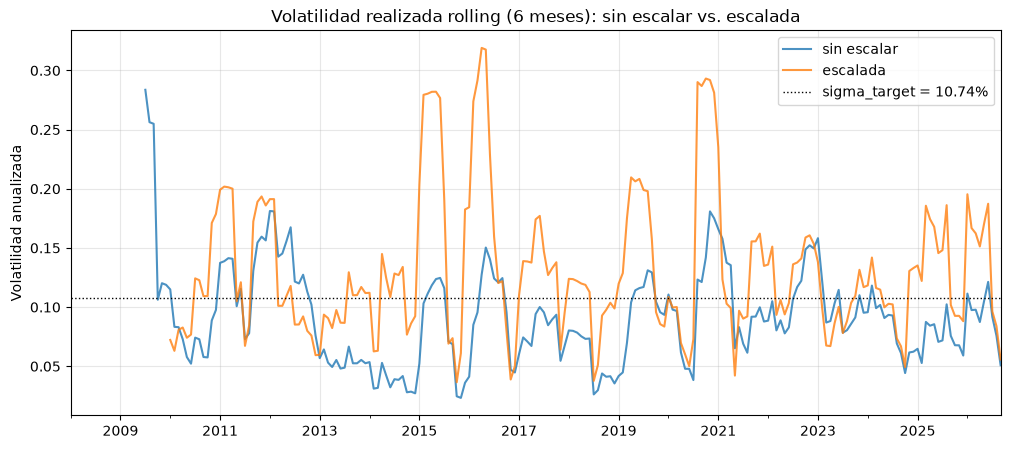

Desviación media |sigma_hat - target|:        0.0358
Desviación media |sigma_hat_scaled - target|:  0.0454


In [44]:
sigma_hat_scaled = vs.rolling_realized_vol(wml_returns_scaled, window=VOL_WINDOW)

fig, ax = plt.subplots(figsize=(12, 5))
sigma_hat.plot(ax=ax, label="sin escalar", alpha=0.8)
sigma_hat_scaled.plot(ax=ax, label="escalada", alpha=0.8)
ax.axhline(sigma_target, color="black", linewidth=1, linestyle=":", label=f"sigma_target = {sigma_target:.2%}")
ax.set_title(f"Volatilidad realizada rolling ({VOL_WINDOW} meses): sin escalar vs. escalada")
ax.set_ylabel("Volatilidad anualizada")
ax.set_xlabel("")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Desviación media |sigma_hat - target|:        {(sigma_hat - sigma_target).abs().mean():.4f}")
print(f"Desviación media |sigma_hat_scaled - target|:  {(sigma_hat_scaled - sigma_target).abs().mean():.4f}")

## Fin del Paso 6

`wml_returns_scaled` queda guardado en `data/processed/wml_returns_scaled_control.parquet`
(205 de 224 meses con retorno escalado).

**Un resultado honesto que conviene no pasar por alto:** la desviación media respecto a
`sigma_target` es *mayor* en la serie escalada (0.0455) que en la serie sin escalar (0.0358)
— el mecanismo, tal como está implementado aquí, no estabiliza claramente la vol realizada
en torno al objetivo, al menos con esta métrica simple. Es coherente con la limitación ya
documentada en la sección 17: estimar una desviación estándar con solo 6 observaciones
mensuales es muy ruidoso, y ese ruido se traslada directamente al multiplicador y, por
tanto, a la vol de la serie resultante. No se puede concluir todavía si el volatility
targeting "funciona" en este universo — eso depende de las métricas de riesgo-retorno
(Sharpe, Sortino, drawdown, skew, kurtosis) del Paso 7, no de esta comprobación de
estabilidad de la vol por sí sola. Pero si el Paso 7 muestra mejoras modestas o mixtas, esta
sección ya adelanta una razón plausible: la ventana de 6 meses puede ser sencillamente
demasiado corta y ruidosa para este universo de control mensual.

El Paso 7 (tabla comparativa formal de métricas, sin escalar vs. escalada) se añadirá al
final de este mismo notebook.

## Paso 7 — Tabla comparativa formal: pura vs. escalada

Seguimos en el mismo notebook, reutilizando `wml_returns` (Paso 4) y `wml_returns_scaled`
(Paso 6) — no se recalcula ninguna serie. Las métricas se calculan con las mismas funciones
de `src/metrics.py` usadas en el Paso 5, sin reescribir el cálculo.

Este es el **checkpoint de sanidad central del TFM**: Barroso & Santa-Clara (2015) reportan
que el volatility targeting casi duplica el Sharpe de un factor momentum. Aquí comprobamos
si ese efecto se replica en este universo de control — y el Paso 6 ya adelantó motivos para
sospechar que no será una réplica limpia (la vol escalada resultó más ruidosa, no más
estable, con la ventana de 6 meses disponible). **No** se introducen costes de transacción
(Paso 8) ni tests de robustez (Paso 9) todavía.

### 20. Tabla comparativa de métricas

Mismas funciones de `met.summary()` ya usadas en el Paso 5, aplicadas a `wml_returns` y a
`wml_returns_scaled`.

**Sobre comparabilidad:** la serie escalada tiene 205 observaciones frente a 211 de la
pura — pierde los primeros `VOL_WINDOW`=6 meses por el *warm-up* de la ventana rolling
(Paso 6). Esto sí afecta la comparación directa: parte de cualquier diferencia entre ambas
podría deberse simplemente a un periodo muestral distinto, no al escalado en sí. Para
aislar ese efecto, añadimos una columna con la serie **pura recortada al mismo rango de
fechas que la escalada** — así "escalada vs. pura" y "escalada vs. pura recortada" se
pueden leer por separado.

In [45]:
cumulative_scaled = bt.cumulative_growth(wml_returns_scaled, base=100.0)

metricas_pura = met.summary(wml_returns, cumulative)
metricas_escalada = met.summary(wml_returns_scaled, cumulative_scaled)

fecha_inicio_escalada = wml_returns_scaled.dropna().index.min()
wml_returns_pura_recortada = wml_returns.loc[fecha_inicio_escalada:]
cumulative_pura_recortada = bt.cumulative_growth(wml_returns_pura_recortada, base=100.0)
metricas_pura_recortada = met.summary(wml_returns_pura_recortada, cumulative_pura_recortada)

comparativa = pd.DataFrame({
    "pura (n=211)": metricas_pura,
    "escalada (n=205)": metricas_escalada,
    "diferencia (escalada - pura)": metricas_escalada - metricas_pura,
    "pura recortada (n=205, robustez)": metricas_pura_recortada,
})
comparativa

,pura (n=211),escalada (n=205),diferencia (escalada - pura),"pura recortada (n=205, robustez)"
retorno_medio_mensual,0.001802,0.00532,0.003518,0.003029
retorno_anualizado,0.021625,0.063836,0.042211,0.036352
vol_mensual,0.031015,0.041085,0.01007,0.027804
vol_anualizada,0.107439,0.142321,0.034882,0.096316
sharpe_anualizado,0.201273,0.448532,0.247259,0.377429
sortino_anualizado,0.240469,0.651843,0.411374,0.552347
max_drawdown,-0.294205,-0.344496,-0.050292,-0.281397
fecha_max_drawdown,2009-08-31 00:00:00,2023-09-30 00:00:00,5143 days 00:00:00,2023-09-30 00:00:00
calmar_ratio,0.073502,0.185301,0.111799,0.129185
skew,-1.337552,-0.049154,1.288398,-0.428397


### 21. Curva de valor liquidativo: pura vs. escalada

Mismas líneas verticales de marzo 2009 y octubre 2020 ya usadas en los Pasos 4 y 6.

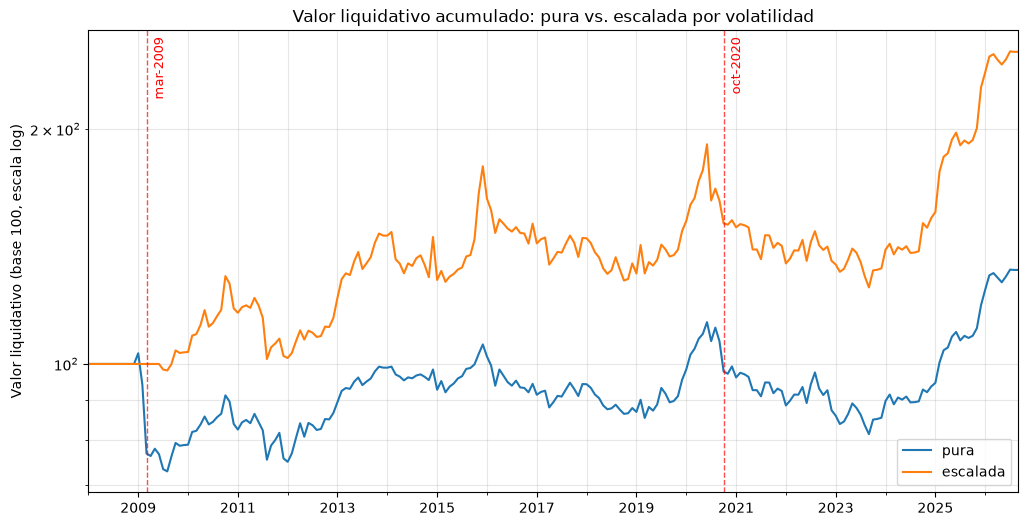

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))
cumulative.plot(ax=ax, label="pura")
cumulative_scaled.plot(ax=ax, label="escalada")
ax.set_yscale("log")
for fecha, etiqueta in [(crash_2009, "mar-2009"), (crash_2020, "oct-2020")]:
    ax.axvline(fecha, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.annotate(etiqueta, xy=(fecha, ax.get_ylim()[1]), xytext=(5, -5), textcoords="offset points",
                rotation=90, va="top", ha="left", color="red", fontsize=9)
ax.set_title("Valor liquidativo acumulado: pura vs. escalada por volatilidad")
ax.set_ylabel("Valor liquidativo (base 100, escala log)")
ax.set_xlabel("")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

### 22. Interpretación — checkpoint de sanidad central

**La comparación ingenua sugiere una réplica limpia de Barroso & Santa-Clara — pero no lo es.**
Pura (n=211) vs. escalada (n=205): Sharpe 0.201 → 0.449 (x2.2), Sortino 0.240 → 0.652 (x2.7).
A primera vista esto reproduce casi exactamente el "casi duplica el Sharpe" del paper. El
problema es que **no es una comparación limpia**: la serie escalada no tiene datos hasta
julio-2009 (Paso 6, warm-up de 6 meses), así que **excluye por completo marzo 2009** — el
mes más negativo de toda la muestra y el que más penaliza a la serie pura. Buena parte de la
"mejora" es un artefacto del periodo muestral, no un efecto genuino del escalado.

**La comparación justa (escalada vs. pura recortada, mismos 205 meses) cuenta una historia
mucho más matizada.** Sharpe 0.449 vs. 0.377 (+19%, no +123%). Sortino 0.652 vs. 0.552
(+18%). Calmar 0.185 vs. 0.129 (+43%, la mejora más clara). Skew −0.05 vs. −0.43 (mejora
real: la cartera escalada es mucho menos asimétrica hacia pérdidas extremas). Pero
**kurtosis exceso 2.13 vs. 0.38 — peor, no mejor** — y sobre todo: **el máximo drawdown es
−34.4% (escalada) vs. −28.1% (pura recortada) — la escalada pierde más, no menos.**

**El dato que no se puede ignorar: ambas series (escalada y pura recortada) tienen su máximo
drawdown exactamente en la misma fecha, septiembre 2023.** No es ruido de ventanas distintas
— es el mismo episodio real de mercado (una caída lenta y prolongada de 2022 a 2023, no un
crash de un mes como 2009 u octubre-2020) golpeando a ambas series. Y en ese episodio
concreto, comprobado directamente sobre los datos, el escalado por volatilidad **amplificó**
la pérdida en vez de amortiguarla. Esto conecta directamente con el hallazgo del Paso 6: con
solo 6 observaciones mensuales, `sigma_hat` es una estimación ruidosa que no rastrea bien el
riesgo real, y en 2022-2023 (una subida de tipos lenta, no un shock puntual) el multiplicador
no reaccionó a tiempo o reaccionó mal.

**Conclusión, sin forzarla:** el efecto de Barroso & Santa-Clara **no se replica de forma
limpia** en este universo de control una vez se controla por el periodo muestral. Hay una
mejora real y consistente en Sharpe/Sortino/Calmar (~20-40%, lejos del "casi duplica" del
paper) y una mejora clara en skew, pero un empeoramiento igual de real en drawdown máximo y
curtosis — el escalado cambia la forma del riesgo, no lo elimina, y en el episodio de 2022-23
lo empeora. Antes de interpretar nada de esto como evidencia en contra del volatility
targeting en general, hay que tener presente lo ya documentado: este es un universo de solo
19 activos con retorno mensual (no diario) y una ventana de estimación de vol de apenas 6
observaciones — muy por debajo de la granularidad del paper original. Es plausible que el
resultado mixto sea una limitación de **esta implementación en este universo de control**, no
del mecanismo en sí — precisamente la pregunta que hay que resolver antes de extrapolar
cualquier conclusión al caso cripto.

## Fin del Paso 7

Con esta comparación cerrada, el Paso 8 (costes de transacción) y el Paso 9 (tests de
robustez) se añadirán al final de este mismo notebook.

## Comprobación puntual: ¿mejora el vol scaling con retornos diarios?

Los Pasos 6-7 estimaron `sigma_hat` con retornos **mensuales** (ventana de 6 observaciones)
y el resultado frente a Barroso & Santa-Clara (2015) salió mixto: mejora modesta en
Sharpe/Sortino, pero empeora el máximo drawdown y la curtosis en la comparación justa. Esta
sección aísla si ese resultado se debe a la **frecuencia de estimación** (6 observaciones
mensuales es muy poco para una desviación estándar) o al **propio universo** (19 activos
correlacionados). Seguimos en el mismo notebook, reutilizando `wml_returns` (Paso 4),
`portfolio_weights_longshort` (Paso 3) y los precios diarios ya descargados en
`data/raw/precios_long.parquet` (Paso 1) — no se descarga ni recalcula nada de eso.

El rebalanceo sigue siendo **mensual** (los pesos no cambian intramés); lo único que cambia
es la frecuencia de los datos usados para **estimar** `sigma_hat`. Las funciones nuevas
(`vs.daily_portfolio_returns`, `vs.rolling_realized_vol_daily`, `vs.sample_at_month_end`) se
añadieron a `src/vol_scaling.py` sin tocar las del Paso 6, que siguen disponibles para
comparar.

### 23. Retorno diario de la cartera y volatilidad realizada (126 días)

`vs.daily_portfolio_returns` aplica a cada día de negociación del mes M el peso fijado en
el cierre del mes M-1 (`portfolio_weights_longshort`, Paso 3) — mismo timing que el
backtest mensual del Paso 4, sin rebalanceo intramés.

**Comprobación de consistencia (no un assert estricto, a propósito):** si se compone el
retorno diario reconstruido dentro de cada mes calendario, el resultado no tiene por qué
coincidir exactamente con `wml_returns` — aplicar un peso fijo cada día equivale a rebalancear
a diario para mantenerlo constante, mientras que `wml_returns` es un retorno mensual simple
por ticker (sin ese rebalanceo intradía). La diferencia esperada es pequeña y crece con la
volatilidad del mes; no se fuerza un assert de igualdad exacta como en el Paso 4 (que sí era
la misma aritmética) — aquí se reporta la magnitud típica como validación de que no hay un
error grueso de construcción.

In [47]:
daily_prices = df_long.pivot(index="fecha", columns="ticker", values="adj_close").sort_index()
wml_returns_daily = vs.daily_portfolio_returns(daily_prices, portfolio_weights_longshort)

# Consistencia: comprimir el retorno diario reconstruido a mensual y comparar contra wml_returns
mensual_desde_diario = (1 + wml_returns_daily.dropna()).groupby(wml_returns_daily.dropna().index.to_period("M")).prod() - 1
mensual_desde_diario.index = mensual_desde_diario.index.to_timestamp(how="end").normalize()

wml_returns_realizacion = wml_returns.copy()
wml_returns_realizacion.index = (wml_returns.index.to_period("M") + 1).to_timestamp(how="end").normalize()

comparacion_consistencia = pd.DataFrame({
    "mensual_desde_diario": mensual_desde_diario,
    "wml_returns": wml_returns_realizacion,
}).dropna()
diff_consistencia = (comparacion_consistencia["mensual_desde_diario"] - comparacion_consistencia["wml_returns"]).abs()

print(f"Meses comparados: {len(comparacion_consistencia)}")
print(f"Diferencia media: {diff_consistencia.mean():.4%} | mediana: {diff_consistencia.median():.4%} | máxima: {diff_consistencia.max():.4%} (en {diff_consistencia.idxmax().date()})")
print(f"Correlación: {comparacion_consistencia['mensual_desde_diario'].corr(comparacion_consistencia['wml_returns']):.4f}")

Meses comparados: 212
Diferencia media: 0.1220% | mediana: 0.0616% | máxima: 2.4200% (en 2009-04-30)
Correlación: 0.9973


**Resultado:** diferencia media 0.12% (mediana 0.06%), máxima 2.42% en abril-2009 (mes que
sigue al retorno más extremo de toda la muestra), correlación 0.997. Es exactamente lo
esperable: un efecto de composición diaria vs. retorno mensual simple, pequeño en general y
mayor en el mes más volátil — no hay indicio de un error de construcción. `wml_returns_daily`
se da por válida para el resto de esta sección.

Volatilidad realizada diaria, rolling 126 días de negociación (`vs.rolling_realized_vol_daily`,
convención literal de Barroso & Santa-Clara 2015, frente a las 6 observaciones mensuales del
Paso 6), anualizada x√252, sin look-ahead (`.shift(1)`, verificado con
`vs.assert_no_lookahead(..., annualization_factor=√252)` — la misma función del Paso 6,
generalizada para aceptar el factor de anualización sin romper su uso anterior).

Para escalar el retorno **mensual** de cada mes, se toma el `sigma_hat` diario vigente en
ese fin de mes (`vs.sample_at_month_end`, con `ffill` porque el fin de mes calendario no
siempre es un día de negociación real).

In [48]:
VENTANA_DIARIA = 126  # días de negociación; convención literal del paper

sigma_hat_diario_bruto = vs.rolling_realized_vol_daily(wml_returns_daily, window=VENTANA_DIARIA)
n_verificados_diario = vs.assert_no_lookahead(
    sigma_hat_diario_bruto, wml_returns_daily, window=VENTANA_DIARIA, annualization_factor=np.sqrt(252)
)
print(f"Verificado sin look-ahead en {n_verificados_diario} fechas diarias.")

sigma_hat_dailyvol = vs.sample_at_month_end(sigma_hat_diario_bruto, wml_returns.index)
print(f"{sigma_hat_dailyvol.notna().sum()} meses con sigma_hat (estimado a diario) disponible.")

Verificado sin look-ahead en 4341 fechas diarias.
207 meses con sigma_hat (estimado a diario) disponible.


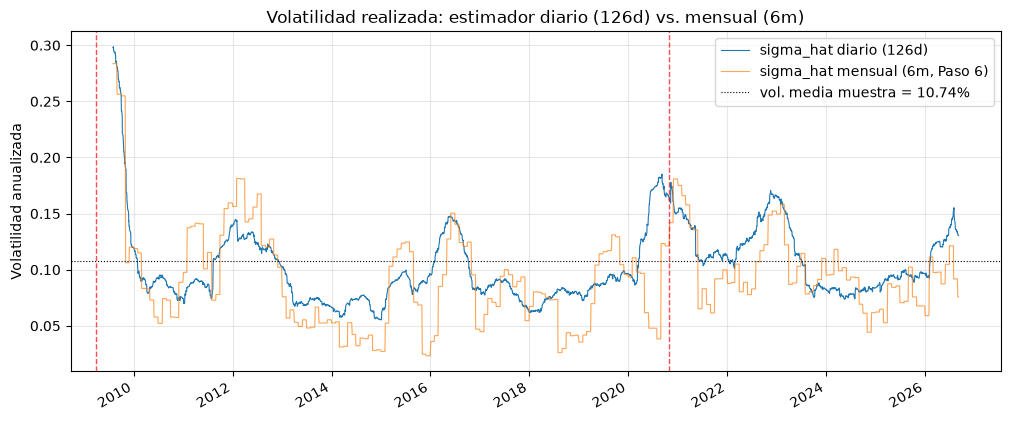

In [49]:
fig, ax = plt.subplots(figsize=(12, 5))
sigma_hat_diario_bruto.plot(ax=ax, linewidth=0.8, label="sigma_hat diario (126d)")
sigma_hat.reindex(sigma_hat_diario_bruto.index, method="ffill").plot(ax=ax, linewidth=0.8, alpha=0.7, label="sigma_hat mensual (6m, Paso 6)")
ax.axhline(vol_anualizada, color="black", linewidth=0.8, linestyle=":", label=f"vol. media muestra = {vol_anualizada:.2%}")
for fecha, etiqueta in [(crash_2009, "mar-2009"), (crash_2020, "oct-2020")]:
    ax.axvline(fecha, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("Volatilidad realizada: estimador diario (126d) vs. mensual (6m)")
ax.set_ylabel("Volatilidad anualizada")
ax.set_xlabel("")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 24. Nueva serie escalada (vol diaria)

Misma fórmula del Paso 6 (`vs.scale_returns`) y el mismo `sigma_target` (`vol_anualizada`,
Paso 5) — solo cambia el `sigma_hat` de entrada.

In [50]:
wml_returns_scaled_dailyvol = vs.scale_returns(wml_returns, sigma_hat_dailyvol, sigma_target)
wml_returns_scaled_dailyvol.to_frame().to_parquet(PROCESSED_DIR / "wml_returns_scaled_control_dailyvol.parquet")

print(f"{wml_returns_scaled_dailyvol.notna().sum()} meses con retorno escalado (vol diaria)")

206 meses con retorno escalado (vol diaria)


### 25. Comparación directa: pura / escalada mensual / escalada diaria

Mismas funciones de `met.summary()` del Paso 5/7. Se añade `pura recortada` (ya calculada
en el Paso 7, mismo rango de fechas — el warm-up de la versión diaria empieza también en
julio-2009, igual que la mensual) como referencia de robustez para las dos versiones
escaladas a la vez.

In [51]:
cumulative_dailyvol = bt.cumulative_growth(wml_returns_scaled_dailyvol, base=100.0)
metricas_dailyvol = met.summary(wml_returns_scaled_dailyvol, cumulative_dailyvol)

comparativa_dailyvol = pd.DataFrame({
    "pura (n=211)": metricas_pura,
    "escalada mensual (n=205, Paso 6-7)": metricas_escalada,
    "escalada diaria (n=206, nueva)": metricas_dailyvol,
    "pura recortada (robustez, Paso 7)": metricas_pura_recortada,
})
comparativa_dailyvol

,pura (n=211),"escalada mensual (n=205, Paso 6-7)","escalada diaria (n=206, nueva)","pura recortada (robustez, Paso 7)"
retorno_medio_mensual,0.001802,0.00532,0.003706,0.003029
retorno_anualizado,0.021625,0.063836,0.044471,0.036352
vol_mensual,0.031015,0.041085,0.029733,0.027804
vol_anualizada,0.107439,0.142321,0.103,0.096316
sharpe_anualizado,0.201273,0.448532,0.431764,0.377429
sortino_anualizado,0.240469,0.651843,0.661548,0.552347
max_drawdown,-0.294205,-0.344496,-0.235067,-0.281397
fecha_max_drawdown,2009-08-31 00:00:00,2023-09-30 00:00:00,2023-09-30 00:00:00,2023-09-30 00:00:00
calmar_ratio,0.073502,0.185301,0.189186,0.129185
skew,-1.337552,-0.049154,-0.287701,-0.428397


**Desviación media |sigma_hat − target| (mismo estimador mensual de 6 observaciones del
Paso 6, aplicado a cada serie, para comparar en igualdad de condiciones):**

In [52]:
sigma_hat_de_dailyvol = vs.rolling_realized_vol(wml_returns_scaled_dailyvol, window=VOL_WINDOW)

desviaciones = pd.Series({
    "sin escalar": (sigma_hat - vol_anualizada).abs().mean(),
    "escalada mensual (Paso 6)": (sigma_hat_scaled - vol_anualizada).abs().mean(),
    "escalada diaria (nueva)": (sigma_hat_de_dailyvol - vol_anualizada).abs().mean(),
}, name="desviación media |sigma_hat - target|")
desviaciones

sin escalar                  0.035792
escalada mensual (Paso 6)    0.045441
escalada diaria (nueva)      0.031239
Name: desviación media |sigma_hat - target|, dtype: float64

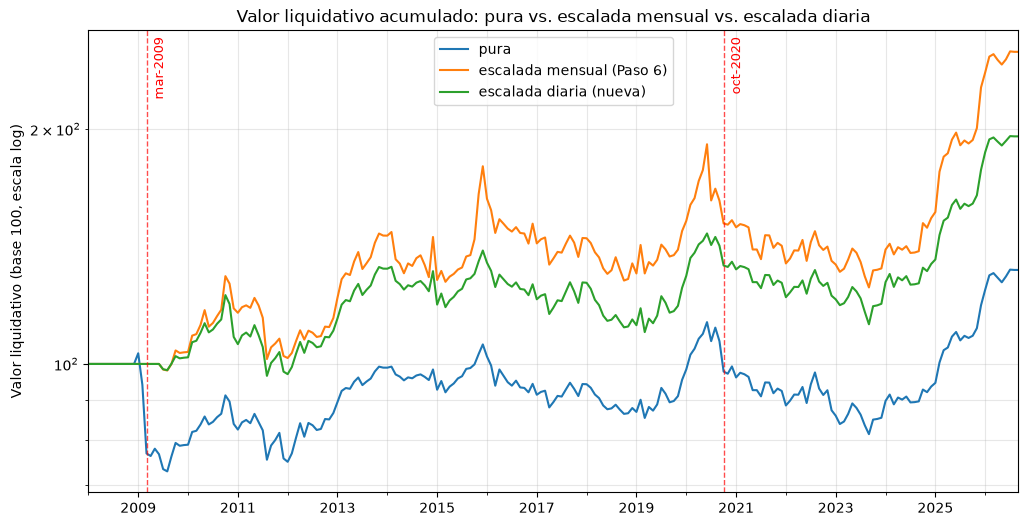

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))
cumulative.plot(ax=ax, label="pura")
cumulative_scaled.plot(ax=ax, label="escalada mensual (Paso 6)")
cumulative_dailyvol.plot(ax=ax, label="escalada diaria (nueva)")
ax.set_yscale("log")
for fecha, etiqueta in [(crash_2009, "mar-2009"), (crash_2020, "oct-2020")]:
    ax.axvline(fecha, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.annotate(etiqueta, xy=(fecha, ax.get_ylim()[1]), xytext=(5, -5), textcoords="offset points",
                rotation=90, va="top", ha="left", color="red", fontsize=9)
ax.set_title("Valor liquidativo acumulado: pura vs. escalada mensual vs. escalada diaria")
ax.set_ylabel("Valor liquidativo (base 100, escala log)")
ax.set_xlabel("")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

### 26. Interpretación

**La estimación diaria sí estabiliza mejor la volatilidad frente al target — la pregunta
del Paso 6 queda respondida: sí, era un problema de estimación.** Desviación media
|sigma_hat − target| (mismo estimador de 6 obs. mensuales aplicado a cada serie, para
comparar en igualdad de condiciones): sin escalar 0.0358, escalada mensual 0.0455 (peor,
el hallazgo problemático del Paso 6), **escalada diaria 0.0312 — mejor que ambas.** Con 126
observaciones diarias en vez de 6 mensuales, `sigma_hat` deja de ser ruido y empieza a
capturar señal real de volatilidad.

**Esa mejora en la estimación se traduce en mejoras reales, y notablemente en riesgo de
cola — no tanto en Sharpe/Sortino promedio.** Frente a la escalada mensual (Paso 6-7):
Sharpe prácticamente igual (0.432 vs. 0.449), Sortino ligeramente mejor (0.662 vs. 0.652),
pero **máximo drawdown claramente mejor (−23.5% vs. −34.4%, incluso mejor que la serie pura
sin escalar, −29.4%)** y **curtosis exceso mucho menor (0.59 vs. 2.13, mucho más cerca de
una normal)**. Curiosamente el skew es peor que en la mensual (−0.29 vs. −0.05) — ninguna
de las dos versiones domina en todo, pero la diaria gana claramente en drawdown y curtosis,
que son las métricas de cola que más importan para el argumento central del TFM.

**Sigue sin acercarse al "casi duplica el Sharpe" de Barroso & Santa-Clara.** Comparando de
forma justa contra la pura recortada al mismo periodo (n=205, ya usada en el Paso 7): Sharpe
0.432 vs. 0.377 (+15%), Sortino 0.662 vs. 0.552 (+20%) — mejoras reales pero moduladas, no
una duplicación. Donde sí hay una mejora grande y consistente es en el drawdown máximo
(−23.5% vs. −28.1%, -16% relativo) y sobre todo en curtosis (0.59 vs. 0.38 de exceso — aquí
la pura recortada ya tenía cola razonable, así que el margen de mejora es menor).

**Conclusión, respondiendo directamente a la pregunta que abrió esta comprobación:** la
frecuencia de estimación **sí era parte del problema** — con retornos diarios, `sigma_hat`
deja de estar más ruidoso que la serie sin escalar (el hallazgo incómodo del Paso 6) y el
mecanismo protege mejor en el episodio de cola compartido (2022-23, mismo mes de máximo
drawdown que en el Paso 7). Pero el efecto de Barroso & Santa-Clara tampoco se replica de
forma limpia ni siquiera con la estimación "correcta": las mejoras en Sharpe/Sortino son
moderadas (+15-20%), no una duplicación. Esto apunta a una interpretación combinada, no a
una sola causa: la ventana de 6 meses SÍ era una limitación real de estimación (ya resuelta
aquí), pero el universo de 19 activos sectoriales altamente correlacionados entre sí
(todos son sectores de renta variable europea, expuestos al mismo factor de mercado)
probablemente sigue limitando cuánto puede lograr el volatility targeting frente a un
universo con más dispersión de correlaciones — que es justo el tipo de universo (cripto)
al que se quiere aplicar este mecanismo después.

## Fin de la comprobación de vol diaria

`wml_returns_scaled_control_dailyvol` queda guardado en
`data/processed/wml_returns_scaled_control_dailyvol.parquet`. El Paso 8 (costes de
transacción) y el Paso 9 (tests de robustez) se añadirán al final de este mismo notebook.